In [ ]:
!pip install pennylane --upgrade
!pip install qutip.qip
!pip install qutip
!pip install qiskit
!pip install qiskit-aer
!pip install "qiskit-aer[qiskit-ibm-provider]"
!pip install -U
!pip install pennylane-qiskit
!pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.0/930.0 kB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.1/30.1 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 

In [ ]:
!sudo apt install cm-super dvipng texlive-latex-extra texlive-latex-recommended

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cm-super-minimal dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern
  fonts-noto-mono fonts-texgyre fonts-urw-base35 ghostscript
  libapache-pom-java libcommons-logging-java libcommons-parent-java
  libfontbox-java libfontenc1 libgs9 libgs9-common libidn12 libijs-0.35
  libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0 libsynctex2
  libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13 lmodern
  pfb2t1c2pfb poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  tex-common tex-gyre texlive-base texlive-binaries texlive-fonts-recommended
  texlive-latex-base texlive-pictures texlive-plain-generic tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf ghostscript-x
  libavalon-fram

In [ ]:
import matplotlib.pyplot as plt
font = {
        'weight' : 'bold',
        'size'   : 16}
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', **font)

In [ ]:
import numpy as np
import pennylane as qml
from pennylane import numpy as np
from qutip import Qobj, tensor, identity, qeye, ket2dm,ptrace
import qutip as qt
import seaborn as sns
from scipy.linalg import expm, sinm, cosm
from qutip_qip.operations import *
from qutip import Qobj, sigmax, sigmay, sigmaz , tensor, qeye,ptrace
import matplotlib.pyplot as plt
import pennylane as qml
from tqdm import tqdm
import qiskit
from qiskit_ibm_runtime.fake_provider import FakeAlmadenV2,FakeAlgiers,FakeBelemV2
from qiskit_aer import noise
from qiskit_aer import AerSimulator
import pandas as pd
import random as random


# Funções

In [ ]:
class QuantumCircuits:
    def __init__(self, num_qubits=2,eb=0.5,shot=1000,type_dev="default.mixed",backend_dev=None):
        #entrada de dados
        self.num_qubits = num_qubits
        self.shot=shot
        if shot==None:
          self.dev = qml.device(type_dev, wires=self.num_qubits)
        if backend_dev==None:
          self.dev = qml.device(type_dev, wires=self.num_qubits,shots=shot)
        else:
          self.dev = qml.device(type_dev, wires=self.num_qubits,shots=shot,backend=backend_dev)
        self._phi_inicial =qml.QNode(self.__phi_inicial,self.dev)
        self._phi_final =qml.QNode(self.__phi_final,self.dev)
        self._caixa_SWAP =qml.QNode(self.__caixa_SWAP,self.dev)
        self._phi_entagled =qml.QNode(self.__phi_entagled,self.dev)
        self.eb=eb

    def thetas_c(self,bb=2,ea=1,ba=1):
      #parametro de correlação
      #parametros do sistema
      bb=bb*ba
      #hamiltoniana do sitema
      sz=np.array([[1, 0], [0, -1]])

      H_A=-0.5*ea*sz
      H_B=-0.5*self.eb*sz

      # Função partição
      Za = np.trace(expm(-ba * H_A))

      Zb = np.trace(expm(-bb * H_B))

      #operador densidade

      p_a=np.exp(ba*ea/2)/Za
      p_b=np.exp(bb*self.eb/2)/Zb
      #coeficiente

      a=1/(Za*Zb)

      pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

      pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

      x=((p_b-p_a)/(pp-pm)+1)*0.5
      #angulo para rotação x
      theta_a=2*np.arccos(np.sqrt(pp))
      theta_b=2*np.arccos(np.sqrt(pm))

      return theta_a,theta_b,x
    def u_minus1(self,x):
        # Calculate the components
        term1 = 1 * np.sqrt(1 - x) * qeye(2)
        term2 = (1j * np.sqrt(x)) * qt.sigmay()
        u_minus = term1 - term2
        return np.array((u_minus).full())

    def u_plus1(self,x):
        # Calculate the components

        term1 = 1 * np.sqrt(1 - x) * qeye(2)
        term2 = (1j * np.sqrt(x)) * qt.sigmay()
        u_minus = term1 + term2

        return np.array((u_minus).full())

    def __phi_entagled(self,theta_A,theta_B,x=0.5):
        qml.RX(theta_A, wires=0)
        qml.RX(theta_B, wires=self.num_qubits-1)

        #caixa termalizado
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[0, i])
          qml.CNOT(wires=[self.num_qubits-1,self.num_qubits-(i+1) ])

        #caixa correlação
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[i,self.num_qubits-(i+1)])
          qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[self.num_qubits-(i+1)], wires=[i])
          qml.CNOT(wires=[i,self.num_qubits-(i+1)])

        #conectar estados termalizados
        for i in range(1,int(self.num_qubits)-1):
          qml.CNOT(wires=[i,(i+1)])
          qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[(i+1)], wires=[i])
          qml.CNOT(wires=[i,(i+1)])

        return qml.state()

    def __phi_inicial(self,theta_A, theta_B,x=0.5):
        qml.RX(theta_A, wires=0)
        qml.RX(theta_B, wires=self.num_qubits-1)

        #caixa termalizado
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[0, i])
          qml.CNOT(wires=[self.num_qubits-1,self.num_qubits-(i+1) ])

        #caixa correlação
        for i in range(1,int(self.num_qubits/2)):
            j=i
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
            qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[self.num_qubits-(j+1)], wires=[i])
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
        if self.shot==None:
          return qml.state()
        if self.num_qubits==8:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3))*0.5-0.5*((qml.PauliZ(4)+qml.PauliZ(5)+qml.PauliZ(6))))
        elif self.num_qubits==10:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3)+qml.PauliZ(4))*0.5-0.5*((qml.PauliZ(5)+qml.PauliZ(6)+qml.PauliZ(7)+qml.PauliZ(8))))
        elif self.num_qubits==12:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3)+qml.PauliZ(4)+qml.PauliZ(5))*0.5-0.5*((qml.PauliZ(6)+qml.PauliZ(7)+qml.PauliZ(8)+qml.PauliZ(9)+qml.PauliZ(10))))
        elif self.num_qubits==6:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2))*0.5-0.5*((qml.PauliZ(3)+qml.PauliZ(4))))
        elif self.num_qubits==4:
          return qml.expval(-self.eb*(qml.PauliZ(1))*0.5-0.5*((qml.PauliZ(2))))


    def __phi_final(self,theta_A,theta_B,x=0.5):

        qml.RX(theta_A, wires=0)
        qml.RX(theta_B, wires=self.num_qubits-1)
        #caixa termalizado
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[0, i])
          qml.CNOT(wires=[self.num_qubits-1,self.num_qubits-(i+1) ])

        #caixa de correlação
        for i in range(1,int(self.num_qubits/2)):
          #for j in range(1,int(self.num_qubits/2)):
            j=i
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
            qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[self.num_qubits-(j+1)], wires=[i])
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])

        #caixa SWAP
        for i in range(1,int(self.num_qubits/2)):
          #for j in range(1,int(self.num_qubits/2)):
            j=i
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
            qml.ControlledQubitUnitary(self.u_plus1(x), control_wires=[self.num_qubits-(j+1)], wires=[i])
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
        if self.shot==0:
          return qml.state()
        if self.num_qubits==8:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3))*0.5-0.5*((qml.PauliZ(4)+qml.PauliZ(5)+qml.PauliZ(6))))
        elif self.num_qubits==10:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3)+qml.PauliZ(4))*0.5-0.5*((qml.PauliZ(5)+qml.PauliZ(6)+qml.PauliZ(7)+qml.PauliZ(8))))
        elif self.num_qubits==12:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3)+qml.PauliZ(4)+qml.PauliZ(5))*0.5-0.5*((qml.PauliZ(6)+qml.PauliZ(7)+qml.PauliZ(8)+qml.PauliZ(9)+qml.PauliZ(10))))
        elif self.num_qubits==6:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2))*0.5-0.5*((qml.PauliZ(3)+qml.PauliZ(4))))
        elif self.num_qubits==4:
          return qml.expval(-self.eb*(qml.PauliZ(1))*0.5-0.5*((qml.PauliZ(2))))


    def __caixa_SWAP(self,x,rho):
      #gerando uma lista com os fios
      wires_list=[]
      for i in range(self.num_qubits):
        wires_list.append(i)

      qml.QubitDensityMatrix(rho, wires=wires_list)
      #caixa swap
      for i in range(self.num_qubits):
        qml.U3(x[i+0],x[i+1],x[i+2], wires=i)

      return qml.state()

    def hamiltoniana(self,eb,ea=1):
      #gerando a matriz identidade para gerar os circuitos
      resultfi=Qobj(np.zeros([2**(self.num_qubits-2),2**(self.num_qubits-2)]),dims=(cnot(self.num_qubits-2,0,1).dims))
      inteiro=int((self.num_qubits)/2)
      #gerando o hamiltoniano para Num Qubits

      for i in range(1,self.num_qubits-1):
        result=Qobj(1)
        for j in range(1,self.num_qubits-1):
          if i==j and i<inteiro:
            result=tensor(result,-ea*qt.sigmaz()/2)

          elif i==j and i>=inteiro:
            result=tensor(result,-eb*qt.sigmaz()/2)

          else:
            result=tensor(result,qeye(2))

        resultfi=resultfi+Qobj(result,dims=cnot(self.num_qubits-2,0,1).dims)

      return resultfi

    #compilador
    def compiled_ibm(self,circuit):#tem que alterar
        compiled_circuit = qml.compile(circuit, pipeline=[
                partial(qml.transforms.commute_controlled, direction="left"), # Now partial is defined
                partial(qml.transforms.merge_rotations, atol=1e-6), # Now partial is defined
                qml.transforms.cancel_inverses
            ],basis_set=["CNOT", "SX", "RZ"],num_passes=4)
        return compiled_circuit

    # Métodos para acessar os circuitos phi_inicial e phi_final
    def get_phi_inicial(self):
        return self.__phi_inicial

    def get_phi_final(self):
        return self.__phi_final
    #truque para gerar a biblioteca do penny lane com POO
    def phi_inicial(self,theta_A, theta_B,x=0.5):
      return self._phi_inicial(theta_A, theta_B,x)

    def phi_entagled(self,theta_A, theta_B,x=0.5):
      return self._phi_entagled(theta_A, theta_B,x)

    def draw(self,function):#resposta temporaria
      qml.draw_mpl(function)(1,1,0.5)
      return

    def caixa_SWAP(self,x,rho):
      return self._caixa_SWAP(x,rho)

    def phi_final(self,theta_A,theta_B,x=0.5):
      return self._phi_final(theta_A,theta_B,x)

class MyGates:
  def __init__(self,num_qubits=2):
    pass
class QuantumMachineLearning:
    dev=None
    def __init__(self,rho,num_qubits=2,epsilon=0.05,eb=0.5):
        self.num_qubits = num_qubits
        self.epsilon=epsilon
        self.eb=eb
        self.rho=rho
        self.trace=np.linspace(1,num_qubits-2,num_qubits-2,dtype=int)
        self.quantum_circuit = QuantumCircuit(self.num_qubits)
        #self.dev = qml.device("default.mixed", wires=self.num_qubits)
        #self.circuit = qml.QNode(self.__circuit, self.dev)

    def loss1(self, rho0, rhof, H):
        #função custo baseado no trabalho
        return np.real(((qt.ptrace(rhof,self.trace) - qt.ptrace(rho0,self.trace)) * H).tr())

    def thetas_c(self,bb=2,ea=1,ba=1):
      #parametro de correlação
      #parametros do sistema
      bb=bb*ba
      #hamiltoniana do sitema
      sz=np.array([[1, 0], [0, -1]])

      H_A=-0.5*ea*sz
      H_B=-0.5*self.eb*sz

      # Função partição
      Za = np.trace(expm(-ba * H_A))

      Zb = np.trace(expm(-bb * H_B))
      #operador densidade

      p_a=np.exp(-ba*ea/2)/Za
      p_b=np.exp(-bb*self.eb/2)/Zb
      #coeficiente

      a=1/(Za*Zb)

      pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

      pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

      x=((p_b-p_a)/(pp-pm)+1)*0.5
      #angulo para rotação x
      theta_a=2*np.arccos(np.sqrt(pp))
      theta_b=2*np.arccos(np.sqrt(pm))

      return theta_a,theta_b,x

    def loss_function(self, params):
        #estado inicial
        rho=self.rho

        rho0 =  qt.Qobj(rho, dims=cnot(self.num_qubits, 0, 1).dims)

        #estado final
        rhof = qt.Qobj(self.quantum_circuit.caixa_SWAP(params, rho), dims=cnot(self.num_qubits, 0, 1).dims)
        H = self.quantum_circuit.hamiltoniana(eb)

        return self.loss1(rho0, rhof, H)

    def parameter_shift_gradient(self, params, j):
        # metod do gradiente
        epsilon = self.epsilon
        shifted_params_plus = params.copy()
        shifted_params_plus[j] += epsilon

        shifted_params_minus = params.copy()
        shifted_params_minus[j] -= epsilon

        gradient = (
            self.loss_function(shifted_params_plus)
            - self.loss_function(shifted_params_minus)
        ) / (2 * epsilon)
        return gradient


    def stochastic_gradient_descent(self, params, learning_rate, num_epochs):
        epoch = 0
        loss = 0
        loss_vec = []
        epochs_vec = []
        #otimizando parametros
        for _ in range(num_epochs):
            #otimização
            for j in range(len(params)):
                gradient = self.parameter_shift_gradient(params, j)
                params[j] -= learning_rate * np.real(gradient)

            loss = self.loss_function(params)
            loss_vec.append(loss)
            epochs_vec.append(epoch)
            epoch += 1
        return params, loss_vec[-1]

class Plots:
  def __init__(self):
    pass
  def plotar(self,x,y,labelx=None,labely=None):
    plt.plot(x,y,'.')
    plt.ylabel(labely)
    plt.xlabel(labelx)
    plt.grid(True)
    plt.show()

# Todas as confugurações para representação não direcionado

Estamos trabalhando em um circuito de 6 qubits seja 4 qubits que serão serão usados para extrair trabalho, os outros dois vão funcionar como ancilas, logo, temos 4 nós, portanto $2^{6}=64$ combinações de arestas considerando que um grafo não-direcionado

In [ ]:
from itertools import product

def gerar_combinacoes_0_1(tamanho):
  """
  Gera todas as combinações possíveis de 0s e 1s em um vetor de tamanho especificado.

  Args:
    tamanho: O tamanho do vetor.

  Returns:
    Uma lista de listas, onde cada lista interna representa uma combinação de 0s e 1s.
  """
  combinacoes = list(product([0, 1], repeat=tamanho))
  return [list(combinacao) for combinacao in combinacoes]

# Teste a função com tamanho = 12
combinacoes_6 = gerar_combinacoes_0_1(6)
#print(combinacoes_6)
print(len(combinacoes_6))

dev1=qml.device("lightning.qubit", wires=6)

def u_minus1(x):
    # Calculate the components
    term1 = 1 * np.sqrt(1 - x) * qeye(2)
    term2 = (1j * np.sqrt(x)) * qt.sigmay()
    u_minus = term1 - term2
    return np.array((u_minus).full())
def u_plus1(x):
    # Calculate the components
    term1 = 1 * np.sqrt(1 - x) * qeye(2)
    term2 = (1j * np.sqrt(x)) * qt.sigmay()
    u_minus = term1 + term2
    return np.array((u_minus).full())
#estado inicial e circuito inicial
@qml.qnode(dev1)
def phi_inicial_geral(num_qubits,eb,lista_adj,theta_A, theta_B,x=0.5):
    qml.RX(theta_A, wires=0)
    qml.RX(theta_B, wires=num_qubits-1)
    for i in range(1,int(num_qubits/2)):
      qml.CNOT(wires=[0, i])
      qml.CNOT(wires=[num_qubits-1,num_qubits-(i+1) ])
    #lista de adjacencia
    for i in lista_adj:
      qml.CNOT(wires=(i))
      qml.ControlledQubitUnitary(u_minus1(x), control_wires=[i[1]], wires=[i[0]])
      qml.CNOT(wires=(i))
    return qml.expval(-eb*(qml.PauliZ(1)+qml.PauliZ(2))*0.5-0.5*((qml.PauliZ(3)+qml.PauliZ(4))))

@qml.qnode(dev1)
def phi_final_geral(num_qubits,eb,lista_adj1,lista_adj2,theta_A,theta_B,x=0.5):
    qml.RX(theta_A, wires=0)
    qml.RX(theta_B, wires=num_qubits-1)
    for i in range(1,int(num_qubits/2)):
      qml.CNOT(wires=[0, i])
      qml.CNOT(wires=[num_qubits-1,num_qubits-(i+1) ])
    #lista de adjacencia para correlação
    for i in lista_adj1:
      qml.CNOT(wires=(i))
      qml.ControlledQubitUnitary(u_minus1(x), control_wires=[i[1]], wires=[i[0]])
      qml.CNOT(wires=(i))
    #lista de adjacênccia para o trabalho
    for i in lista_adj2:
      qml.CNOT(wires=(i))
      qml.ControlledQubitUnitary(u_plus1(x), control_wires=[i[1]], wires=[i[0]])
      qml.CNOT(wires=(i))
    return qml.expval(-eb*(qml.PauliZ(1)+qml.PauliZ(2))*0.5-0.5*((qml.PauliZ(3)+qml.PauliZ(4))))

@qml.qnode(dev1)
def teste(initial_state,num_qubits,x=0.5):
    qml.QubitStateVector(initial_state, wires=range(int(num_qubits)))
    for i in range(1,int(num_qubits/2)):
      for j in range(1,int(num_qubits/2)):
        qml.CNOT(wires=[i,num_qubits-(j+1)])
        qml.ControlledQubitUnitary(u_plus1(x), control_wires=[num_qubits-(j+1)], wires=[i])
        qml.CNOT(wires=[i,num_qubits-(j+1)])
    return qml.state()



def hab(num_qubits,eb,ea=1):
  #gerando a matriz identidade para gerar os circuitos
  resultfi=Qobj(np.zeros([2**(num_qubits-2),2**(num_qubits-2)]),dims=(cnot(num_qubits-2,0,1).dims))
  inteiro=int((num_qubits)/2)
  #gerando o hamiltoniano para Num Qubits

  for i in range(1,num_qubits-1):
    result=Qobj(1)
    for j in range(1,num_qubits-1):
      if i==j and i<inteiro:
        result=tensor(result,-ea*qt.sigmaz()/2)

      elif i==j and i>=inteiro:
        result=tensor(result,-eb*qt.sigmaz()/2)

      else:
        result=tensor(result,qeye(2))

    resultfi=resultfi+Qobj(result,dims=cnot(num_qubits-2,0,1).dims)

  return resultfi.full()

64


In [ ]:
from tqdm import tqdm
#todas as permutações
listas_qubits=[(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]#
num_qubits=6
ebs=np.linspace(0,1,20)
matriz_ener=np.zeros((len(combinacoes_6),len(combinacoes_6),20))
#criando a lista de adjacencia
for j,comb1 in tqdm(enumerate(combinacoes_6[:8])):
  #print(sum(comb1),comb1)
  if sum(comb1)>7 or sum(comb1)<2:
    continue
  lista_adj1=[]
  for i,k in enumerate(comb1):
    # condição para criar a lista de adjacência para a caixa de correlação
    if k==1:
      lista_adj1.append(list(listas_qubits[i]))
    ## estado inicial
    #phi_inicial=phi_inicial_geral(num_qubits,lista_adj1,theta_A, theta_B,x=0.5)
    for l,comb2 in enumerate(combinacoes_6):
      if sum(comb2)>7 or sum(comb2)<2:
        continue
      lista_adj2=[]
      for m,n in enumerate(comb2):
        # condição para criar a lista de adjacência para a caixa de trabalho
        if n==1:
          lista_adj2.append(list(listas_qubits[m]))
      for o,eb in enumerate(ebs):
        # condições
        theta_A,theta_B,x=QuantumCircuit(num_qubits,eb).thetas_c()

        # estado inicial
        phi_inicial=phi_inicial_geral(num_qubits,eb,lista_adj1,theta_A, theta_B,x)

        # estado final
        phi_final=phi_final_geral(num_qubits,eb,lista_adj1,lista_adj2,theta_A,theta_B,x)

        #print(phi_inicial-phi_final)
        matriz_ener[j][l][o]=phi_inicial-phi_final
# --- Preparando para criar o DataFrame ---

# Criar rótulos para as linhas e colunas baseados em combinacoes_6
row_labels = [str(comb) for comb in combinacoes_6]
col_labels = row_labels  # As colunas também usam as combinações

# --- Criar e salvar o DataFrame ---

# A matriz 'matriz_ener' tem 3 dimensões. Vamos remodelá-la para 2D para o DataFrame
# Cada 'eb' será uma coluna no DataFrame final, e as combinações de linha/coluna serão índices
dataframes = []
for i, eb in enumerate(ebs):
    df = pd.DataFrame(matriz_ener[:, :, i], index=row_labels, columns=col_labels)
    # Adicionar uma coluna 'eb' para indicar o valor de eb para cada DataFrame
    df['eb'] = eb
    df['comb_index_row'] = df.index  # Adiciona uma coluna com os valores dos índices das linhas
    df = df.set_index(['eb', 'comb_index_row'])  # Define 'eb' e o índice da linha como MultiIndex
    dataframes.append(df)

# Concatenar todos os DataFrames em um único DataFrame
final_df = pd.concat(dataframes)

# Salvar o DataFrame em um arquivo CSV
final_df.to_csv('matriz_ener.csv')

print("DataFrame salvo em 'matriz_ener.csv'")

0it [00:00, ?it/s]/usr/local/lib/python3.10/dist-packages/pennylane/devices/preprocess.py:284: UserWarning: Differentiating with respect to the input parameters of Sum is not supported with the adjoint differentiation method. Gradients are computed only with regards to the trainable parameters of the circuit.

 Mark the parameters of the measured observables as non-trainable to silence this warning.
  warnings.warn(
16it [1:18:15, 293.47s/it]


NameError: name 'pd' is not defined

In [ ]:
from tqdm import tqdm
#todas as permutações
listas_qubits=[(1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]#
num_qubits=6
ebs=np.linspace(0,1,20)
matriz_ener=np.zeros((len(combinacoes_6),len(combinacoes_6),20))
#criando a lista de adjacencia
for j,comb1 in tqdm(enumerate(combinacoes_6[17:32])):
  #print(sum(comb1),comb1)
  if sum(comb1)>7 or sum(comb1)<2:
    continue
  lista_adj1=[]
  for i,k in enumerate(comb1):
    # condição para criar a lista de adjacência para a caixa de correlação
    if k==1:
      lista_adj1.append(list(listas_qubits[i]))
    ## estado inicial
    #phi_inicial=phi_inicial_geral(num_qubits,lista_adj1,theta_A, theta_B,x=0.5)
    for l,comb2 in enumerate(combinacoes_6):
      if sum(comb2)>7 or sum(comb2)<2:
        continue
      lista_adj2=[]
      for m,n in enumerate(comb2):
        # condição para criar a lista de adjacência para a caixa de trabalho
        if n==1:
          lista_adj2.append(list(listas_qubits[m]))
      for o,eb in enumerate(ebs):
        # condições
        theta_A,theta_B,x=QuantumCircuit(num_qubits,eb).thetas_c()

        # estado inicial
        phi_inicial=phi_inicial_geral(num_qubits,eb,lista_adj1,theta_A, theta_B,x)

        # estado final
        phi_final=phi_final_geral(num_qubits,eb,lista_adj1,lista_adj2,theta_A,theta_B,x)

        #print(phi_inicial-phi_final)
        matriz_ener[j][l][o]=phi_inicial-phi_final

0it [00:00, ?it/s]/usr/local/lib/python3.10/dist-packages/pennylane/devices/preprocess.py:284: UserWarning: Differentiating with respect to the input parameters of Sum is not supported with the adjoint differentiation method. Gradients are computed only with regards to the trainable parameters of the circuit.

 Mark the parameters of the measured observables as non-trainable to silence this warning.
  warnings.warn(
15it [1:52:47, 451.14s/it]


# Teste de velocidade

In [ ]:
dev1=qml.device("lightning.qubit", wires=6)
@qml.qnode(dev1)
def phi_final_geral(num_qubits,eb,lista_adj1,lista_adj2,theta_A,theta_B,x=0.5):
    qml.RX(theta_A, wires=0)
    qml.RX(theta_B, wires=num_qubits-1)
    for i in range(1,int(num_qubits/2)):
      qml.CNOT(wires=[0, i])
      qml.CNOT(wires=[num_qubits-1,num_qubits-(i+1) ])
    #lista de adjacencia para correlação
    for i in lista_adj1:
      qml.CNOT(wires=(i))
      qml.ControlledQubitUnitary(u_minus1(x), control_wires=[i[1]], wires=[i[0]])
      qml.CNOT(wires=(i))
    #lista de adjacênccia para o trabalho
    for i in lista_adj2:
      qml.CNOT(wires=(i))
      qml.ControlledQubitUnitary(u_plus1(x), control_wires=[i[1]], wires=[i[0]])
      qml.CNOT(wires=(i))
    return qml.expval(-eb*(qml.PauliZ(1)+qml.PauliZ(2))*0.5-0.5*((qml.PauliZ(3)+qml.PauliZ(4))))

num_qubits=6
eb=0.5
lista_adj1=[[1, 2],[1, 3], [1, 4], [2, 3], [2, 4], [3, 4]]
theta_A,theta_B,x=QuantumCircuit(num_qubits,eb).thetas_c()
%timeit phi_final_geral(num_qubits,eb,lista_adj1,lista_adj1,theta_A,theta_B,x)

156 ms ± 26.1 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
!pip install cutensornet-cu12
!pip install pennylane-lightning-tensor

In [ ]:
!pip install pennylane
!pip install cuquantum-python
!pip install pennylane-lightning[gpu]

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 MB 6.8 MB/s eta 0:00:00
  Created wheel for cuquantum-python: filename=cuquantum_python-24.11.0-0_cu12-py3-none-any.whl size=6407 sha256=43ac73a7f205c64899cfc111afdc56d913f96e0062f9236561a05169ee01780b
  Stored in directory: /root/.cache/pip/wheels/ee/29/a4/4e8092d11efa1b414cb34041efedc349b9a4d5492ee1daf4ba
Successfully built cuquantum-python
  Attempting uninstall: cupy-cuda12x
    Found existing installation: cupy-cuda12x 12.2.0
    Uninstalling cupy-cuda12x-12.2.0:
      Successfully uninstalled cupy-cuda12x-12.2.0


In [ ]:
dev1=qml.device("lightning.tensor", wires=6, method="tn")
@qml.qnode(dev1)
def phi_final_geral(num_qubits,eb,lista_adj1,lista_adj2,theta_A,theta_B,x=0.5):
    qml.RX(theta_A, wires=0)
    qml.RX(theta_B, wires=num_qubits-1)
    for i in range(1,int(num_qubits/2)):
      qml.CNOT(wires=[0, i])
      qml.CNOT(wires=[num_qubits-1,num_qubits-(i+1) ])
    #lista de adjacencia para correlação
    for i in lista_adj1:
      qml.CNOT(wires=(i))
      qml.ControlledQubitUnitary(u_minus1(x), control_wires=[i[1]], wires=[i[0]])
      qml.CNOT(wires=(i))
    #lista de adjacênccia para o trabalho
    for i in lista_adj2:
      qml.CNOT(wires=(i))
      qml.ControlledQubitUnitary(u_plus1(x), control_wires=[i[1]], wires=[i[0]])
      qml.CNOT(wires=(i))
    return qml.expval(-eb*(qml.PauliZ(1)+qml.PauliZ(2))*0.5-0.5*((qml.PauliZ(3)+qml.PauliZ(4))))

num_qubits=6
eb=0.5
lista_adj1=[[1, 2],[1, 3], [1, 4], [2, 3], [2, 4], [3, 4]]
theta_A,theta_B,x=QuantumCircuit(num_qubits,eb).thetas_c()
%timeit phi_final_geral(num_qubits,eb,lista_adj1,lista_adj1,theta_A,theta_B,x)

ImportError: Pre-compiled binaries for lightning.tensor are not available. 

#Todas as combinações de circuito
Estamos trabalhando em um circuito de 6 qubits seja 4 qubits que serão serão usados para extrair trabalho, os outros dois vão funcionar como ancilas, logo, temos 4 nós, portanto $2^{12}=4096$ combinações de arestas considerando que se for um grafo será direcionado.

In [ ]:
lista=[(1, 2), (1, 3), (1, 4), (2, 1), (2, 3), (2, 4), (3, 1), (3, 2), (3, 4), (4, 1), (4, 2), (4, 3)]

In [ ]:
dev1=qml.device("default.mixed", wires=6)

def u_minus1(x):
    # Calculate the components
    term1 = 1 * np.sqrt(1 - x) * qeye(2)
    term2 = (1j * np.sqrt(x)) * qt.sigmay()
    u_minus = term1 - term2
    return np.array((u_minus).full())
def u_plus1(x):
    # Calculate the components
    term1 = 1 * np.sqrt(1 - x) * qeye(2)
    term2 = (1j * np.sqrt(x)) * qt.sigmay()
    u_minus = term1 + term2
    return np.array((u_minus).full())
#estado inicial e circuito inicial
@qml.qnode(dev1)
def phi_inicial(num_qubits,theta_A, theta_B,x=0.5):
    qml.RX(theta_A, wires=0)
    qml.RX(theta_B, wires=num_qubits-1)
    for i in range(1,int(num_qubits/2)):
      qml.CNOT(wires=[0, i])
      qml.CNOT(wires=[num_qubits-1,num_qubits-(i+1) ])
    for i in range(1,int(num_qubits/2)):
      for j in range(1,int(num_qubits/2)):
        qml.CNOT(wires=[i,num_qubits-(j+1)])
        qml.ControlledQubitUnitary(u_minus1(x), control_wires=[num_qubits-(j+1)], wires=[i])
        qml.CNOT(wires=[i,num_qubits-(j+1)])
    return qml.state()

@qml.qnode(dev1)
def phi_final(num_qubits,theta_A,theta_B,x=0.5):
    qml.RX(theta_A, wires=0)
    qml.RX(theta_B, wires=num_qubits-1)
    for i in range(1,int(num_qubits/2)):
      qml.CNOT(wires=[0, i])
      qml.CNOT(wires=[num_qubits-1,num_qubits-(i+1) ])
    for i in range(1,int(num_qubits/2)):
      for j in range(1,int(num_qubits/2)):
        qml.CNOT(wires=[i,num_qubits-(j+1)])
        qml.ControlledQubitUnitary(u_minus1(x), control_wires=[num_qubits-(j+1)], wires=[i])
        qml.CNOT(wires=[i,num_qubits-(j+1)])
    for i in range(1,int(num_qubits/2)):
      for j in range(1,int(num_qubits/2)):
        qml.CNOT(wires=[i,num_qubits-(j+1)])
        qml.ControlledQubitUnitary(u_plus1(x), control_wires=[num_qubits-(j+1)], wires=[i])
        qml.CNOT(wires=[i,num_qubits-(j+1)])
    return qml.state()

@qml.qnode(dev1)
def teste(initial_state,num_qubits,x=0.5):
    qml.QubitStateVector(initial_state, wires=range(int(num_qubits)))
    for i in range(1,int(num_qubits/2)):
      for j in range(1,int(num_qubits/2)):
        qml.CNOT(wires=[i,num_qubits-(j+1)])
        qml.ControlledQubitUnitary(u_plus1(x), control_wires=[num_qubits-(j+1)], wires=[i])
        qml.CNOT(wires=[i,num_qubits-(j+1)])
    return qml.state()



    def hamiltoniana(self,eb,ea=1):
      #gerando a matriz identidade para gerar os circuitos
      resultfi=Qobj(np.zeros([2**(self.num_qubits-2),2**(self.num_qubits-2)]),dims=(cnot(self.num_qubits-2,0,1).dims))
      inteiro=int((self.num_qubits)/2)
      #gerando o hamiltoniano para Num Qubits

      for i in range(1,self.num_qubits-1):
        result=Qobj(1)
        for j in range(1,self.num_qubits-1):
          if i==j and i<inteiro:
            result=tensor(result,-ea*qt.sigmaz()/2)

          elif i==j and i>=inteiro:
            result=tensor(result,-eb*qt.sigmaz()/2)

          else:
            result=tensor(result,qeye(2))

        resultfi=resultfi+Qobj(result,dims=cnot(self.num_qubits-2,0,1).dims)

      return resultfi

In [ ]:
print(list(lista[0]))
print(list(lista[0][::-1]))

[1, 2]
[2, 1]
[1, 2]
[2, 1]


(<Figure size 500x400 with 1 Axes>, <Axes: >)

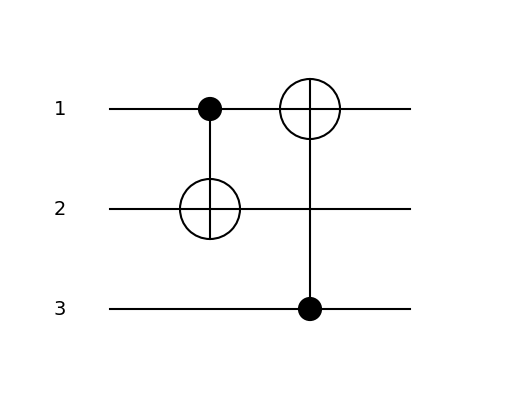

(<Figure size 500x400 with 1 Axes>, <Axes: >)

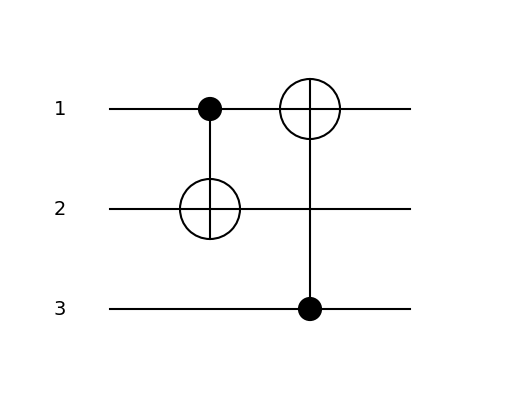

In [ ]:
dev1=qml.device("default.mixed", wires=4)
@qml.qnode(dev1)
def teste():
    qml.CNOT(wires=list(lista[0]))
    qml.CNOT(wires=list(lista[1][::-1]))

qml.draw_mpl(teste)()

# Estado X
Encontrar a seguinte solução


## Solução

### Solução Analitica

In [ ]:
import sympy as sp
import numpy as np

# Define as variáveis simbólicas
pp, pm, x, y, pra, prb = sp.symbols('pp pm x y pra prb')

# Define as expressões para p00, p01, p10 e p11
p00 = sp.cos(pp)**2 * sp.cos(pm)**2
p01 = sp.cos(pp)**2 * sp.sin(pm)**2
p10 = sp.sin(pp)**2 * sp.cos(pm)**2
p11 = sp.sin(pp)**2 * sp.sin(pm)**2

# Define as expressões para w, z, a, b, c e d
w = (p00 - p10) * sp.sin(x)* sp.cos(x)
z = (p01 - p11) * sp.sin(y)* sp.cos(y)
a = p00 * sp.cos(y)**2 + p10 * sp.sin(y)**2
b = p11 * sp.cos(x)**2 + p01 * sp.sin(x)**2
c = p01 * sp.cos(x)**2 + p11 * sp.sin(x)**2
d = p10 * sp.cos(y)**2 + p00 * sp.sin(y)**2

# Define o sistema de equações
eq1 = sp.Eq(pra, a + b)
eq2 = sp.Eq(prb, a + c)
eq3 = sp.Eq(sp.Symbol('alpha'),(p11 - p01)*sp.sin(y) * sp.cos(y))
eq4 = sp.Eq(sp.Symbol('beta'), (p00 - p10) * sp.sin(x) * sp.cos(x))

# Resolve o sistema de equações simbolicamente
solution = sp.solve([eq1, eq2, eq3, eq4], (pp, pm, y, x))

# Converte a solução simbólica para funções numéricas
# (Exemplo com a primeira solução, se houver múltiplas soluções)
if solution:
    pp_func = sp.lambdify((pra, prb), solution[0][0], 'numpy')
    pm_func = sp.lambdify((pra, prb), solution[0][1], 'numpy')
    y_func = sp.lambdify((pra, prb), solution[0][2], 'numpy')
    x_func = sp.lambdify((pra, prb), solution[0][3], 'numpy')

    # Exemplo de uso com valores numéricos para pra e prb
    pra_val = 0.5
    prb_val = 0.7
    pp_val = pp_func(pra_val, prb_val)
    pm_val = pm_func(pra_val, prb_val)
    y_val = y_func(pra_val, prb_val)
    x_val = x_func(pra_val, prb_val)

    print(f"pp = {pp_val}")
    print(f"pm = {pm_val}")
    print(f"y = {y_val}")
    print(f"x = {x_val}")
else:
    print("Não foi encontrada solução para o sistema de equações.")

KeyboardInterrupt: 

### Númerica

In [ ]:
import numpy as np
from scipy.optimize import fsolve

def equations(vars, pra, prb, alpha, beta):
    pp, pm = vars

    p00 = np.cos(pp)**2 * np.cos(pm)**2
    p01 = np.cos(pp)**2 * np.sin(pm)**2
    p10 = np.sin(pp)**2 * np.cos(pm)**2
    p11 = np.sin(pp)**2 * np.sin(pm)**2

    #w = (p00 - p10) * np.sin(x)* np.cos(x)
    #z = (p01 - p11) * np.sin(y) * np.cos(y)
    #print(alpha,beta)
    #print(p00,p01,p10,p11)
    #print(2*alpha/(p00-p10))
    #print(2*beta/(p01-p11))

    x= alpha
    y= beta

    a = p00 * np.cos(y)**2 + p10 * np.sin(y)**2
    b = p11 * np.cos(x)**2 + p01 * np.sin(x)**2
    c = p01 * np.cos(x)**2 + p11 * np.sin(x)**2
    d = p10 * np.cos(y)**2 + p00 * np.sin(y)**2

    eq1 = a + b - pra
    eq2 = a + c - prb
    #eq3 = alpha - (p01 - p11) * np.sin(y) * np.cos(y)
    #eq4 = beta - (p00 - p10) * np.sin(x) * np.cos(x)

    return [eq1, eq2]

# Example usage with pra = 0.6 and prb = 0.8
ea=eb=ba=1
bb=2*ba
#hamiltoniana do sitema
sz=np.array([[1, 0], [0, -1]])

H_A=-0.5*ea*sz
H_B=-0.5*eb*sz

# Função partição
Za = np.trace(expm(-ba * H_A))

Zb = np.trace(expm(-bb * H_B))
#operador densidade

p_a=np.exp(-ba*ea/2)/Za
p_b=np.exp(-bb*eb/2)/Zb

pra = p_a
prb = p_b


alphas=betas=np.linspace(-np.pi,np.pi,100)
initial_guess = [random.random(),random.random()] # Initial guess for pp, pm, y, x

#gerando uma matriz
matriz_pm=np.zeros((len(alphas),len(betas)))
matriz_pp=np.zeros((len(alphas),len(betas)))

for i,alpha in enumerate(alphas):
  for j,beta in enumerate(betas):
    initial_guess = [np.pi*random.random(),np.pi*random.random()] # Initial guess for pp, pm, y, x
    solution = fsolve(equations, initial_guess, args=(pra, prb, alpha, beta))
    matriz_pm[i][j]=solution[0]
    matriz_pp[i][j]=solution[1]

print(f"pp = {pp}")
print(f"pm = {pm}")

<ipython-input-5-cc072325362c>:66: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  solution = fsolve(equations, initial_guess, args=(pra, prb, alpha, beta))
<ipython-input-5-cc072325362c>:66: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  solution = fsolve(equations, initial_guess, args=(pra, prb, alpha, beta))


NameError: name 'pp' is not defined

In [ ]:
import numpy as np
from scipy.optimize import fsolve

def equations(vars, pra, prb, alpha, beta):

    pp, pm, y, x = vars

    p00 = np.cos(pp)**2 * np.cos(pm)**2
    p01 = np.cos(pp)**2 * np.sin(pm)**2
    p10 = np.sin(pp)**2 * np.cos(pm)**2
    p11 = np.sin(pp)**2 * np.sin(pm)**2

    w = (p00 - p10) * np.sin(x)* np.cos(x)
    z = (p01 - p11) * np.sin(y) * np.cos(y)

    a = p00 * np.cos(y)**2 + p10 * np.sin(y)**2
    b = p11 * np.cos(x)**2 + p01 * np.sin(x)**2
    c = p01 * np.cos(x)**2 + p11 * np.sin(x)**2
    d = p10 * np.cos(y)**2 + p00 * np.sin(y)**2

    eq1 = a + b - pra
    eq2 = a + c - prb
    eq3 = (p01 - p11) * np.sin(y) * np.cos(y)-alpha
    eq4 = (p00 - p10) * np.sin(x) * np.cos(x)-beta

    return [eq1, eq2, eq3, eq4]

# Example usage with pra = 0.6 and prb = 0.8
ea=0.1
eb=ba=1
bb=2*ba
#hamiltoniana do sitema
sz=np.array([[1, 0], [0, -1]])

H_A=-0.5*ea*sz
H_B=-0.5*eb*sz

# Função partição
Za = np.trace(expm(-ba * H_A))

Zb = np.trace(expm(-bb * H_B))
#operador densidade

p_a=np.exp(-ba*ea/2)/Za
p_b=np.exp(-bb*eb/2)/Zb

pra = p_a
prb = p_b
alpha = 1/(Za*Zb)
beta = 1/(Za*Zb)
initial_guess = [random.random(),random.random(),random.random(),random.random()] # Initial guess for pp, pm, y, x

solution = fsolve(equations, initial_guess, args=(pra, prb, alpha, beta), xtol=1e-8, maxfev=1000)

pp, pm, y, x = solution

print(f"pp = {pp}")
print(f"pm = {pm}")
print(f"y = {y}")
print(f"x = {x}")

pp = 1.5713290865253116
pm = 0.7266811971902327
y = -0.3868085616627762
x = -0.3119593017574278


<ipython-input-91-dfe117632e93>:53: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last five Jacobian evaluations.
  solution = fsolve(equations, initial_guess, args=(pra, prb, alpha, beta), xtol=1e-8, maxfev=1000)


In [ ]:
import numpy as np
from scipy.optimize import minimize
from scipy.linalg import expm

def equations(vars, pra, prb, x, y):
  """
  Calcula pm e pp que satisfazem as equações para pra e prb dados.

  Args:
    vars: Uma lista contendo os valores de pm e pp.
    pra: Valor de pra.
    prb: Valor de prb.
    alpha: Valor de alpha.
    beta: Valor de beta.

  Returns:
    Uma lista contendo as equações para pra e prb.
  """
  pp, pm= vars

  p00 = np.cos(pp)**2 * np.cos(pm)**2
  p01 = np.cos(pp)**2 * np.sin(pm)**2
  p10 = np.sin(pp)**2 * np.cos(pm)**2
  p11 = np.sin(pp)**2 * np.sin(pm)**2

  w = (p00 - p10) * np.sin(x)* np.cos(x)
  z = (p01 - p11) * np.sin(y) * np.cos(y)

  a = p00 * np.cos(y)**2 + p10 * np.sin(y)**2
  b = p11 * np.cos(x)**2 + p01 * np.sin(x)**2
  c = p01 * np.cos(x)**2 + p11 * np.sin(x)**2
  d = p10 * np.cos(y)**2 + p00 * np.sin(y)**2


  eq1 = a + b - pra
  eq2 = a + c - prb

  #eq3 = (p00 - p10) * np.sqrt(y * (1 - y)) - alpha
  #eq4 = (p01 - p11) * np.sqrt(x * (1 - x)) - beta

  return [eq1, eq2]

# Exemplo de uso

# Example usage with pra = 0.6 and prb = 0.8

ea=0.25
ea=eb=ba=1
bb=2*ba

#hamiltoniana do sitema

sz=np.array([[1, 0], [0, -1]])

H_A=-0.5*ea*sz
H_B=-0.5*eb*sz

# Função partição

Za = np.trace(expm(-ba * H_A))

Zb = np.trace(expm(-bb * H_B))

#operador densidade

p_a=np.exp(-ba*ea/2)/Za
p_b=np.exp(-bb*eb/2)/Zb

pra = p_a
prb = p_b


initial_guess = [np.pi*2*random.random(),np.pi*2*random.random()]# Chute inicial para pm, pp, alpha e beta

# Bounds for the variables (assuming 0 <= x, y <= 1)

bounds = [(-np.pi, np.pi), (-np.pi, np.pi)]

#gerando uma matriz

matriz_pm=np.zeros((len(alphas),len(betas)))
matriz_pp=np.zeros((len(alphas),len(betas)))


#alphas e betas

alphas=betas=np.linspace(-np.pi,np.pi,100)

for i,alpha in enumerate(alphas):
  for j,beta in enumerate(betas):
    initial_guess = [np.pi*random.random(),np.pi*random.random()] # Initial guess for pp, pm, y, x
    # Use minimize with bounds
    result = minimize(
        lambda vars, pra, prb, alpha, beta: np.sum(np.array(equations(vars, pra, prb, alpha, beta))**2),
        initial_guess,
        args=(pra, prb, alpha, beta),
        bounds=bounds)
    if result.success:
        pm, pp = result.x
        matriz_pm[i][j]=pm
        matriz_pp[i][j]=pp
    else:
        print("Optimization failed:", result.message)

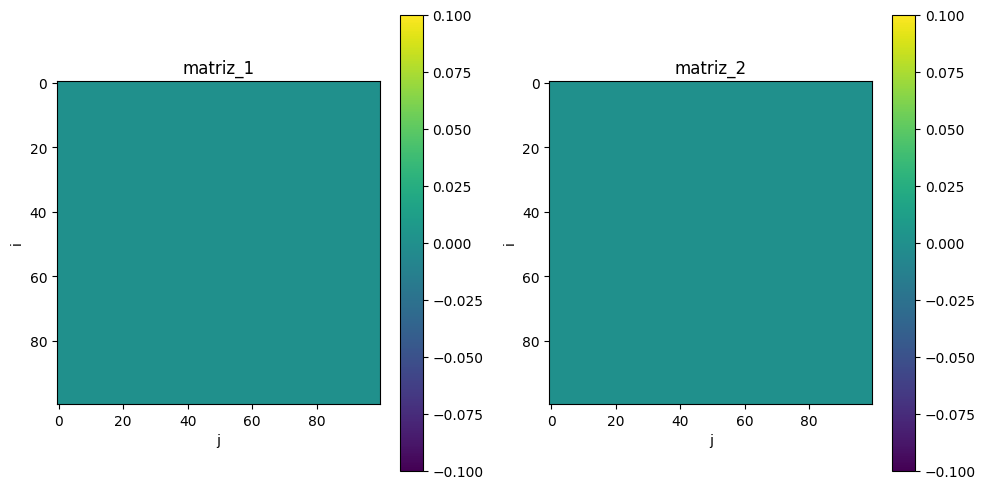

In [ ]:
# Create heatmaps
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Heatmap for matriz_pm
im1 = axes[0].imshow(matriz_certo1, cmap='viridis')
axes[0].set_title('matriz_1')
axes[0].set_xlabel('j')
axes[0].set_ylabel('i')
plt.colorbar(im1, ax=axes[0])

# Heatmap for matriz_pp
im2 = axes[1].imshow(matriz_certo2, cmap='viridis')
axes[1].set_title('matriz_2')
axes[1].set_xlabel('j')
axes[1].set_ylabel('i')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

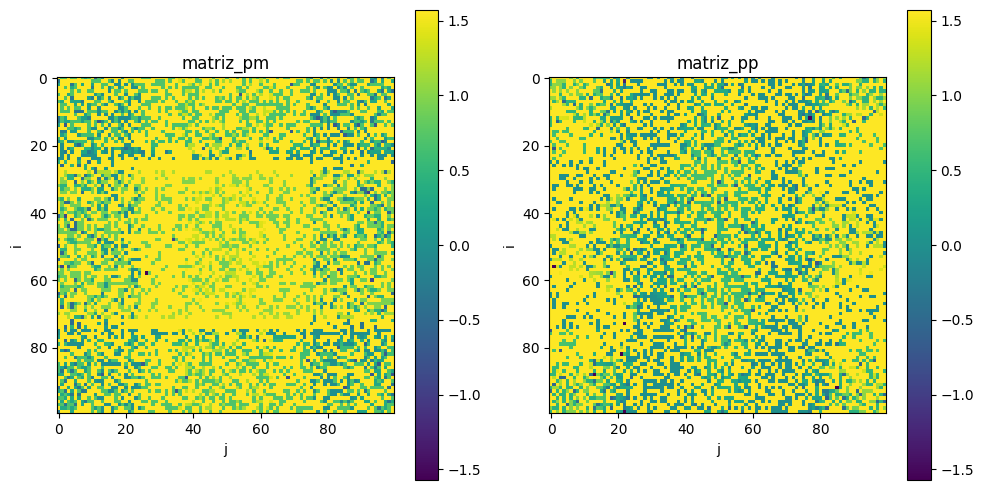

In [ ]:
# Create heatmaps
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Heatmap for matriz_pm
im1 = axes[0].imshow(matriz_pm, cmap='viridis')
axes[0].set_title('matriz_pm')
axes[0].set_xlabel('j')
axes[0].set_ylabel('i')
plt.colorbar(im1, ax=axes[0])

# Heatmap for matriz_pp
im2 = axes[1].imshow(matriz_pp, cmap='viridis')
axes[1].set_title('matriz_pp')
axes[1].set_xlabel('j')
axes[1].set_ylabel('i')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

#### Verificar
Priramente iremos testar se os valores direto daram certo!

In [ ]:
#Criando estado
def estado_X(pp,pm,x,y):
  #matrizes termicas

  p00 = np.cos(pp)**2 * np.cos(pm)**2
  p01 = np.cos(pp)**2 * np.sin(pm)**2
  p10 = np.sin(pp)**2 * np.cos(pm)**2
  p11 = np.sin(pp)**2 * np.sin(pm)**2

  w = (p00 - p10) * np.sin(x)* np.cos(x)
  z = (p01 - p11) * np.sin(y) * np.cos(y)

  a = p00 * np.cos(y)**2 + p10 * np.sin(y)**2
  b = p11 * np.cos(x)**2 + p01 * np.sin(x)**2
  c = p01 * np.cos(x)**2 + p11 * np.sin(x)**2
  d = p10 * np.cos(y)**2 + p00 * np.sin(y)**2
  #matriz final
  rho_X=np.array([
      [a, 0, 0, z],
      [0, b, w, 0],
      [0, w, c, 0],
      [z, 0, 0, d]
  ])
  return rho_X

In [ ]:
def calcular_concorrencia_qutip_estado_x(pp, pm, x, y):
    """
    Calcula a concorrência do estado X usando QuTiP's concurrence function.

    Args:
        pp: Parâmetro pp do estado X.
        pm: Parâmetro pm do estado X.
        x: Parâmetro x do estado X.
        y: Parâmetro y do estado X.

    Returns:
        A concorrência do estado X.
    """
    rho_x_np = estado_X(pp, pm, x, y)  # Get the NumPy representation
    rho_x_qobj = qt.Qobj(rho_x_np,dims=[[2,2],[2,2]])        # Convert to a QuTiP Qobj

    concorrencia = qt.concurrence(rho_x_qobj)
    return concorrencia

In [ ]:
def calcular_informacao_mutua_qutip_estado_x(pp, pm, x, y):
    """
    Calcula a informação mútua do estado X usando QuTiP.

    Args:
        pp: Parâmetro pp do estado X.
        pm: Parâmetro pm do estado X.
        x: Parâmetro x do estado X.
        y: Parâmetro y do estado X.

    Returns:
        A informação mútua do estado X (retirada do estado bipartido 4x4).
        Retorna None se o estado for inválido (matriz não positiva ou com traço != 1).
    """
    rho_x_np = estado_X(pp, pm, x, y)
    rho_x_qobj = Qobj(rho_x_np)

    # Check if the density matrix is valid
    #if not rho_x_qobj.is_positive() or abs(rho_x_qobj.tr() - 1) > 1e-9:  # Tolerance for trace
        #print("Warning: Invalid density matrix. Check your estado_X function.")
        #return None

    # Assuming the state is on a 4x4 system (two qubits)
    # We want to compute the mutual information between the two subsystems (A and B)

    # Trace over the second subsystem (B) to get reduced density matrix of A
    rho_a = rho_x_qobj.ptrace([0,1]) #Keep the first two indices, tracing over the last two
    # Trace over the first subsystem (A) to get reduced density matrix of B
    rho_b = rho_x_qobj.ptrace([2,3]) #Keep the last two indices, tracing over the first two

    # Calculate the von Neumann entropy of the full system and the subsystems
    entropy_rho_x = qt.entropy_vn(rho_x_qobj)
    entropy_rho_a = qt.entropy_vn(rho_a)
    entropy_rho_b = qt.entropy_vn(rho_b)

    # Calculate the mutual information
    mutual_info = entropy_rho_a + entropy_rho_b - entropy_rho_x

    return mutual_info

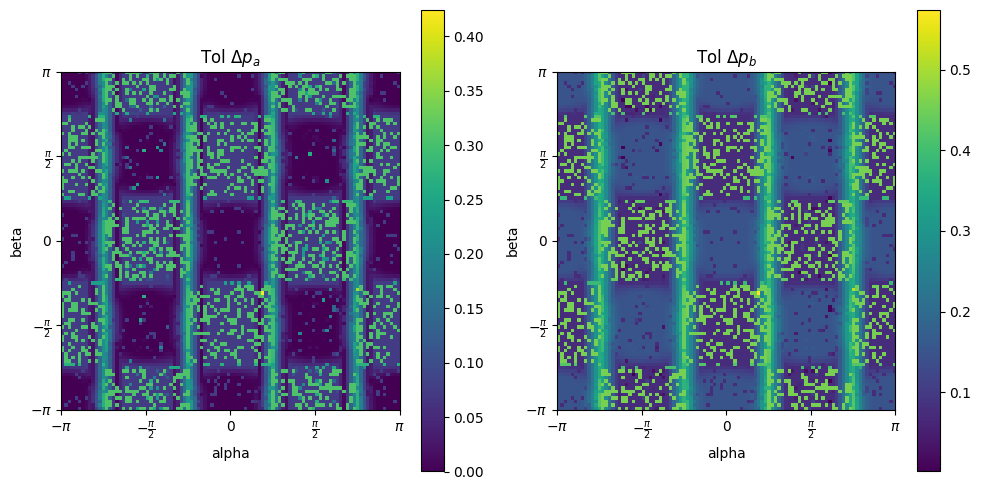

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ... (your existing code for estado_X, pm, pp, pra, prb, alphas, betas) ...

matriz_certo1 = np.zeros((len(alphas), len(betas)))
matriz_certo2 = np.zeros((len(alphas), len(betas)))

matriz_concurrence = np.zeros((len(alphas), len(betas)))
matriz_mutual_quant = np.zeros((len(alphas), len(betas)))

#verificando se o resultado deu certo!
for i,x in enumerate(alphas):
  for j,y in enumerate(betas):
    rho_teste=estado_X(matriz_pm[i][j],matriz_pp[i][j],x,y)

    matriz_certo1[i][j]=abs(pra-(rho_teste[0][0]+rho_teste[1][1]))
    matriz_certo2[i][j]=abs(prb-(rho_teste[0][0]+rho_teste[1][1]))

    #matriz_concurrence[i][j]=calcular_concorrencia_qutip_estado_x(pp, pm, x, y)
    #matriz_mutual_quant[i][j]=calcular_informacao_mutua_qutip_estado_x(pp, pm, x, y)

# Create heatmaps
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Heatmap for matriz_pm
im1 = axes[0].imshow(matriz_certo1, cmap='viridis', extent=[alphas.min(), alphas.max(), betas.min(), betas.max()], origin='lower')  # Key changes here
axes[0].set_title('Tol $\Delta p_{a}$')
axes[0].set_xlabel('alpha')  # More descriptive labels
axes[0].set_ylabel('beta')   # More descriptive labels
plt.colorbar(im1, ax=axes[0])

# Heatmap for matriz_pp
im2 = axes[1].imshow(matriz_certo2, cmap='viridis', extent=[alphas.min(), alphas.max(), betas.min(), betas.max()], origin='lower')  # Key changes here
axes[1].set_title('Tol $\Delta p_{b}$')
axes[1].set_xlabel('alpha')  # More descriptive labels
axes[1].set_ylabel('beta')   # More descriptive labels
plt.colorbar(im2, ax=axes[1])


# Set x and y axis ticks and labels for -pi to pi
axes[0].set_xticks(np.linspace(-np.pi, np.pi, 5)) # Example: 5 ticks
axes[0].set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$']) # LaTeX formatting for pi
axes[0].set_yticks(np.linspace(-np.pi, np.pi, 5)) # Example: 5 ticks
axes[0].set_yticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$']) # LaTeX formatting for pi

axes[1].set_xticks(np.linspace(-np.pi, np.pi, 5)) # Example: 5 ticks
axes[1].set_xticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$']) # LaTeX formatting for pi
axes[1].set_yticks(np.linspace(-np.pi, np.pi, 5)) # Example: 5 ticks
axes[1].set_yticklabels([r'$-\pi$', r'$-\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$']) # LaTeX formatting for pi


plt.tight_layout()
plt.show()

In [ ]:
rho_teste=estado_X(pm,pp,x,y)
print(rho_teste)
print(p_a)
print(p_b)
print(rho_teste[0][0]+rho_teste[1][1])
print(rho_teste[0][0]+rho_teste[2][2])

[[0.09616084 0.         0.         0.        ]
 [0.         0.17321204 0.         0.        ]
 [0.         0.         0.70707047 0.        ]
 [0.         0.         0.         0.02355665]]
0.26894142136999516
0.11920292202211756
0.26937287472922833
0.80323130701402


In [ ]:
import math

def calculate_probabilities(p_A, p_B, alpha, beta):
    """
    Calculates p_+, p_-, x, and y based on the given parameters.

    Args:
        p_A: Probability of event A.
        p_B: Probability of event B.
        alpha: Parameter alpha.
        beta: Parameter beta.

    Returns:
        A tuple containing p_plus, p_minus, x, and y.  Returns None if a
        division by zero would occur.
    """

    try:
        # Calculate y
        term1_y = 16 * alpha**2 * beta**2
        term2_y = (p_A - p_B) * (-1 + p_A + p_B)
        print(16 * alpha**2 * beta**2, term2_y**2)
        print(p_A,p_B)
        term3_y = np.sqrt((2*alpha + p_A - p_B)*(2*alpha - p_A + p_B)*(16 * alpha**2 * beta**2 - term2_y**2))
        numerator_y = term1_y + (-1 + p_A + p_B) * (-term2_y + term3_y)
        denominator_y = 32 * alpha**2 * beta**2 - 2 * term2_y**2
        y = numerator_y / denominator_y

        # Calculate x
        numerator_x = alpha + (p_A - p_B) * math.sqrt((alpha**2 * (4*beta**2 - (-1 + p_A - p_B)**2)) / (16*alpha**2*beta**2 - term2_y**2))
        denominator_x = 2 * alpha
        x = numerator_x / denominator_x

        # Calculate p_+
        numerator_p_plus = -p_A * x + (-1 + p_A + 2*x)*y - p_B*(-1 + x + y)
        denominator_p_plus = (-1 + 2*x)*(-1 + 2*y)
        p_plus = numerator_p_plus / denominator_p_plus

        # Calculate p_-
        numerator_p_minus = (-1 + p_A + p_B)*(-1 + 2*x)
        denominator_p_minus = 1 + 2*(-1 + p_A)*x - 2*p_A*y + 2*p_B*(-1 + x + y)
        p_minus = numerator_p_minus / denominator_p_minus

        return p_plus, p_minus, x, y

    except ZeroDivisionError:
        return None  # Or handle the error as needed


# Exemplo de uso
# Example usage with pra = 0.6 and prb = 0.8
ea=0.0
eb=ba=1
bb=2*ba
#hamiltoniana do sitema
sz=np.array([[1, 0], [0, -1]])

H_A=-0.5*ea*sz
H_B=-0.5*eb*sz

# Função partição
Za = np.trace(expm(-ba * H_A))

Zb = np.trace(expm(-bb * H_B))
#operador densidade

p_a=np.exp(-ba*ea/2)/Za
p_b=np.exp(-bb*eb/2)/Zb

pra = p_a
prb = p_b

alpha = 1/(Za*Zb)
beta = 1/(Za*Zb)

results = calculate_probabilities(p_a, p_b, alpha, beta)

if results:
    pp, pm, x, y = results
    print(f"p_+: {pp}")
    print(f"p_-: {pm}")
    print(f"x: {x}")
    print(f"y: {y}")
else:
    print("Error: Division by zero occurred.")

0.011023652975883421 0.021026860274130154
0.5 0.11920292202211756
p_+: 0.6403283713551179
p_-: 0.32462500995958526
x: 1.504484308634921
y: 2.5898068821762124


In [ ]:
np.isclose(equations((pm, pp, x, y), pra, prb, alpha, beta), [pra, prb, alpha, beta])

array([False, False, False, False])

Fui derrotado??

Após diversas tentativas, devo segui a ideia no artigo que usei para gerar o estado-x informa os angulo de máximo emaranhamento, utilizarei essa informação

Consegui vencer

Tive que dar dois passos para trás e olhar o artigo da Irene novamente, após isso consegui encontrar uma solução para o problema

## Controlled unitary e Transpilação

### Exemplo

In [ ]:
!pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136816 sha256=c42af9713a9a4db4c941ec38fbccd2572b996d9ecc437fcc644187be235cb977
  Stored in directory: /root/.cache/pip/wheels/b1/7a/33/9fdd892f784ed4afda62b685ae3703adf4c91aa0f524c28f03
Successfully built pylatexenc


In [ ]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library.standard_gates import HGate

qr = QuantumRegister(3)
qc = QuantumCircuit(qr)
c3h_gate = HGate().control(2)
qc.append(c3h_gate, qr)
qc.draw()

q1_0: ──■──
        │  
q1_1: ──■──
      ┌─┴─┐
q1_2: ┤ H ├
      └───┘

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library.standard_gates import HGate

qr = QuantumRegister(3)
qc = QuantumCircuit(qr)
c3h_gate = HGate().control(2)
qc.append(c3h_gate, [0,2,1])
qc.draw()

q1_0: ──■──
      ┌─┴─┐
q1_1: ┤ H ├
      └─┬─┘
q1_2: ──■──

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.library.standard_gates import HGate

qc1 = QuantumCircuit(2)
qc1.x(0)
qc1.h(1)
custom = qc1.to_gate().control(2)

qc2 = QuantumCircuit(4)
qc2.append(custom, [0, 3, 1, 2])
qc2.draw()

q_0: ───────■────────
     ┌──────┴───────┐
q_1: ┤0             ├
     │  circuit-169 │
q_2: ┤1             ├
     └──────┬───────┘
q_3: ───────■────────

### Aplicando

In [ ]:
qc1 = QuantumCircuit(1)
#gerando porta
Quan7=QuantumCircuits(2,0.1,1000)
theta_a,theta_b,x=Quan7.thetas_c()
qc1.u(theta_a,theta_b,x,0)
custom = qc1.to_gate().control(1)
#gerando porta unitária
qc2 = QuantumCircuit(4)
qc2.append(custom, [0,1])

#qc2 = transpile(qc2, basis_gates=['cx', 'id', 'rz', 'x', 'sx'])
qc2.draw()

q_0: ───────■───────
     ┌──────┴──────┐
q_1: ┤ circuit-191 ├
     └─────────────┘
q_2: ───────────────
                    
q_3: ───────────────

In [ ]:
circuit = QuantumCircuit(1)
circuit.u(theta_a,theta_b,x,0)
circuit.draw()

┌──────────────────────────┐
q: ┤ U(1.3734,2.4308,0.68997) ├
   └──────────────────────────┘

In [ ]:
# Crie um circuito quântico com 2 qubits
qc = QuantumCircuit(2)

# Adicione a porta RXX com um ângulo de rotação pi/2
qc.rxx(np.pi/2, 0, 1)

# Meça os qubits
qc.draw()


┌───────────┐
q_0: ┤0          ├
     │  Rxx(π/2) │
q_1: ┤1          ├
     └───────────┘

## Decomposição

## Meu exemplo

In [ ]:
qc1 = QuantumCircuit(1)
theta_a,theta_b,x=Quan7.thetas_c()
qc1.u(theta_a,theta_b,x,0)

qc1 = transpile(qc1, basis_gates=['cx', 'id', 'rz', 'x', 'sx'])
print(qc1)

NameError: name 'Quan7' is not defined

## Aplicando

In [ ]:
qc1 = QuantumCircuit(1)
#gerando porta
Quan7=QuantumCircuits(2,0.1,1000)
theta_a,theta_b,x=Quan7.thetas_c()
qc1.u(theta_a,theta_b,x,0)
custom = qc1.to_gate().control(1)
#gerando porta unitária
qc2 = QuantumCircuit(4)
qc2.append(custom, [0,1])
#imprimir ciruito
print(qc2)

# transpilar Heron
qc4 = transpile(qc2, basis_gates=['cz', 'id', 'rz', 'x', 'sx'])
# Meça os qubits
print(qc4)



# transpilar Eagle
qc6 = transpile(qc2, basis_gates=['ecr', 'id', 'rz', 'x', 'sx'])
# Meça os qubits
print(qc6)


NameError: name 'QuantumCircuits' is not defined

In [ ]:
# Crie um circuito quântico com 2 qubits
qc3 = QuantumCircuit(2)

# Adicione a porta RXX com um ângulo de rotação pi/2
qc3.rxx(np.pi/16, 0, 1)

print(qc3)

# transpilar Heron
qc4 = transpile(qc3, basis_gates=['cz', 'id', 'rz', 'x', 'sx'])
# Meça os qubits
print(qc4)



# transpilar Eagle
qc6 = transpile(qc3, basis_gates=['ecr', 'id', 'rz', 'x', 'sx'])
# Meça os qubits
print(qc6)


     ┌────────────┐
q_0: ┤0           ├
     │  Rxx(π/16) │
q_1: ┤1           ├
     └────────────┘
     ┌─────────┐┌────┐┌─────────┐                                         »
q_0: ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─■───────────────────────────────────────»
     └─────────┘└────┘└─────────┘ │ ┌─────────┐┌────┐┌─────────────┐┌────┐»
q_1: ─────────────────────────────■─┤ Rz(π/2) ├┤ √X ├┤ Rz(-15π/16) ├┤ √X ├»
                                    └─────────┘└────┘└─────────────┘└────┘»
«                   ┌─────────┐┌────┐┌─────────┐
«q_0: ────────────■─┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├
«     ┌─────────┐ │ └─────────┘└────┘└─────────┘
«q_1: ┤ Rz(π/2) ├─■─────────────────────────────
«     └─────────┘                               
global phase: 3π/4
     ┌─────────┐   ┌────┐  ┌──────┐     ┌───┐     ┌──────────┐          »
q_0: ┤ Rz(π/2) ├───┤ √X ├──┤0     ├─────┤ X ├─────┤ Rz(-π/2) ├──────────»
     └──┬────┬─┘┌──┴────┴─┐│  Ecr │┌────┴───┴────┐└──┬────┬──┘┌────────┐»
q_1: ───┤ √X ├──┤ Rz(π/2) ├┤1     

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate
x=0.5
matrix = [[np.sqrt(1-x), 0, 0, -np.sqrt(x)],
          [0, np.sqrt(1-x), -np.sqrt(x), 0],
          [0, np.sqrt(x), np.sqrt(1-x), 0],
          [np.sqrt(x), 0, 0, np.sqrt(1-x)]]
gate = UnitaryGate(matrix)

circuit = QuantumCircuit(2)
circuit.append(gate, [0, 1])
print(circuit)

     ┌──────────┐
q_0: ┤0         ├
     │  Unitary │
q_1: ┤1         ├
     └──────────┘


In [ ]:
# transpilar Heron
qc4 = transpile(circuit, basis_gates=['cz', 'id', 'rz', 'x', 'sx'])
# Meça os qubits
print(qc4)



# transpilar Eagle
qc6 = transpile(circuit, basis_gates=['ecr', 'id', 'rz', 'x', 'sx'])
# Meça os qubits
print(qc6)

global phase: 3π/4
     ┌──────────┐┌────┐   ┌─────────┐┌────┐┌──────────┐
q_0: ┤ Rz(-π/2) ├┤ √X ├─■─┤ Rz(π/2) ├┤ √X ├┤ Rz(-π/2) ├
     └──┬────┬──┘└────┘ │ ├─────────┤├────┤└┬────────┬┘
q_1: ───┤ √X ├──────────■─┤ Rz(π/2) ├┤ √X ├─┤ Rz(-π) ├─
        └────┘            └─────────┘└────┘ └────────┘ 
global phase: π
     ┌──────────┐┌────┐┌──────┐┌────────┐   ┌────┐  ┌─────────┐
q_0: ┤ Rz(-π/2) ├┤ √X ├┤0     ├┤ Rz(-π) ├───┤ √X ├──┤ Rz(π/2) ├
     ├──────────┤├────┤│  Ecr │└─┬────┬─┘┌──┴────┴─┐└─────────┘
q_1: ┤ Rz(-π/2) ├┤ √X ├┤1     ├──┤ √X ├──┤ Rz(π/2) ├───────────
     └──────────┘└────┘└──────┘  └────┘  └─────────┘           


# Relatório

## Metodologia

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import circuit_drawer
# Import the CXGate (CNOT) explicitly or use QuantumCircuit.cx
from qiskit.circuit.library import CXGate

# Define o número de qubits
num_qubits = 4

# Cria um circuito quântico com 4 qubits e 4 bits clássicos
qr = QuantumRegister(num_qubits, 'q')
cr = ClassicalRegister(num_qubits, 'c')
circuit = QuantumCircuit(qr, cr)

# Adiciona as portas quânticas
circuit.rx(0.4, qr[0])  # Porta Rx(theta_A) no qubit 0
circuit.rx(0.2, qr[3])  # Porta Rx(theta_B) no qubit 3

# Portas CNOT para criar estados emaranhados
circuit.cx(qr[0], qr[1])
circuit.cx(qr[1], qr[2])
circuit.cx(qr[2], qr[3])

# Adiciona as portas U_-, U_+, U
circuit.u(0.5, 0.3, 0.1, qr[0])  # Porta U no qubit 0
circuit.u(0.2, 0.4, 0.6, qr[1])  # Porta U no qubit 1
circuit.u(0.7, 0.1, 0.9, qr[2])  # Porta U no qubit 2
circuit.u(0.3, 0.6, 0.2, qr[3])  # Porta U no qubit 3

# Adiciona as medidas
circuit.measure(qr, cr)

# Desenha o circuito
circuit_drawer(circuit, output='mpl', filename='circuito_quantico.png')

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.22330494  0.          0.          0.26702917]
 [ 0.          0.11177397 -0.09332999  0.        ]
 [ 0.         -0.09332999  0.19720032  0.        ]
 [ 0.26702917  0.          0.          0.46772078]]


(<Figure size 1200x500 with 1 Axes>, <Axes: >)

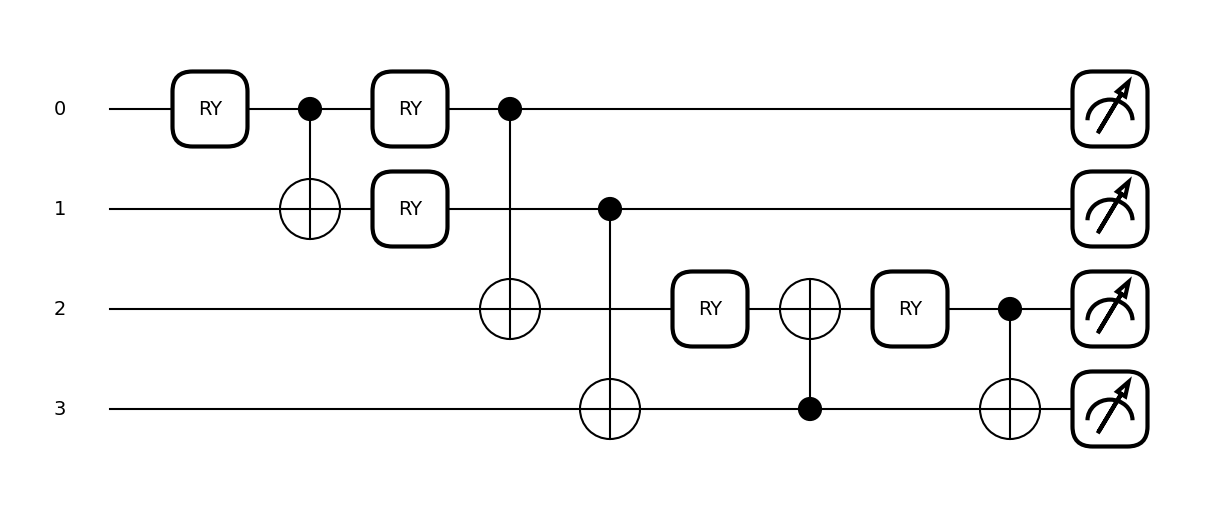

In [ ]:
import pennylane as qml
from pennylane import numpy as np

# Assuming you have angles alpha, beta, gamma, theta, and phi defined

dev = qml.device("default.qubit", wires=4)  # 4 qubits

@qml.qnode(dev)
def X_state(alpha, beta, gamma, theta, phi):
    qml.RY(alpha, wires=0)
    qml.CNOT(wires=[0, 1])
    qml.RY(beta, wires=0)
    qml.RY(gamma, wires=1)
    qml.CNOT(wires=[0, 2])
    qml.CNOT(wires=[1, 3])
    qml.RY(theta + phi, wires=2)
    qml.CNOT(wires=[3, 2])
    qml.RY(theta - phi, wires=2)
    qml.CNOT(wires=[2,3])
    return qml.state()

# Execute the circuit (replace with your actual angle values)
alpha, beta, gamma, theta, phi=np.pi/4,1,1,1,1
result =X_state(alpha, beta, gamma, theta, phi)
rho=Qobj(np.outer(result,np.conjugate(result)),dims=cnot(4,0,1).dims)
print(ptrace(rho,[2,3]))
qml.draw_mpl(X_state)(1,1,1,1,1)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.27176314+0.j         0.        +0.j         0.        +0.j
  0.        +0.13526023j]
 [0.        +0.j         0.08110673+0.j         0.        -0.13526023j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.13526023j 0.49838801+0.j
  0.        +0.j        ]
 [0.        -0.13526023j 0.        +0.j         0.        +0.j
  0.14874211+0.j        ]]


(<Figure size 900x500 with 1 Axes>, <Axes: >)

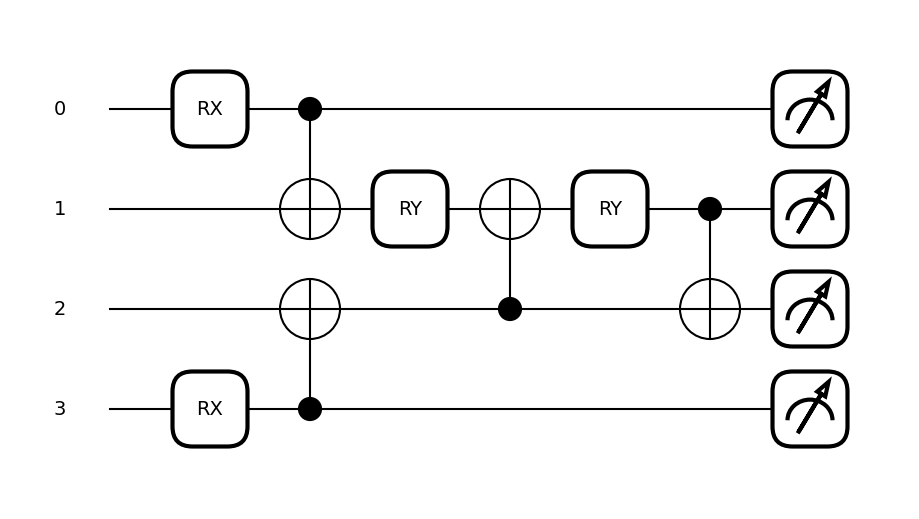

In [ ]:
import pennylane as qml
from pennylane import numpy as np

# Assuming you have angles alpha, beta, gamma, theta, and phi defined

dev = qml.device("default.qubit", wires=4)  # 4 qubits

@qml.qnode(dev)
def X_state(alpha, beta, gamma, theta, phi):
    qml.RX(alpha, wires=0)
    qml.CNOT(wires=[0, 1])
    qml.RX(beta, wires=3)
    qml.CNOT(wires=[3, 2])
    qml.RY(theta + phi, wires=1)
    qml.CNOT(wires=[2, 1])
    qml.RY(theta - phi, wires=1)
    qml.CNOT(wires=[1,2])
    return qml.state()

# Execute the circuit (replace with your actual angle values)
alpha, beta, gamma, theta, phi=np.pi/4,1,1,1,1
result =X_state(alpha, beta, gamma, theta, phi)
rho=Qobj(np.outer(result,np.conjugate(result)),dims=cnot(4,0,1).dims)
print(ptrace(rho,[2,3]))
qml.draw_mpl(X_state)(1,1,1,1,1)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.77015115+0.j         0.        +0.j         0.        +0.j
  0.        +0.42073549j]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j        ]
 [0.        +0.j         0.        +0.j         0.        +0.j
  0.        +0.j        ]
 [0.        -0.42073549j 0.        +0.j         0.        +0.j
  0.22984885+0.j        ]]


(<Figure size 1400x500 with 1 Axes>, <Axes: >)

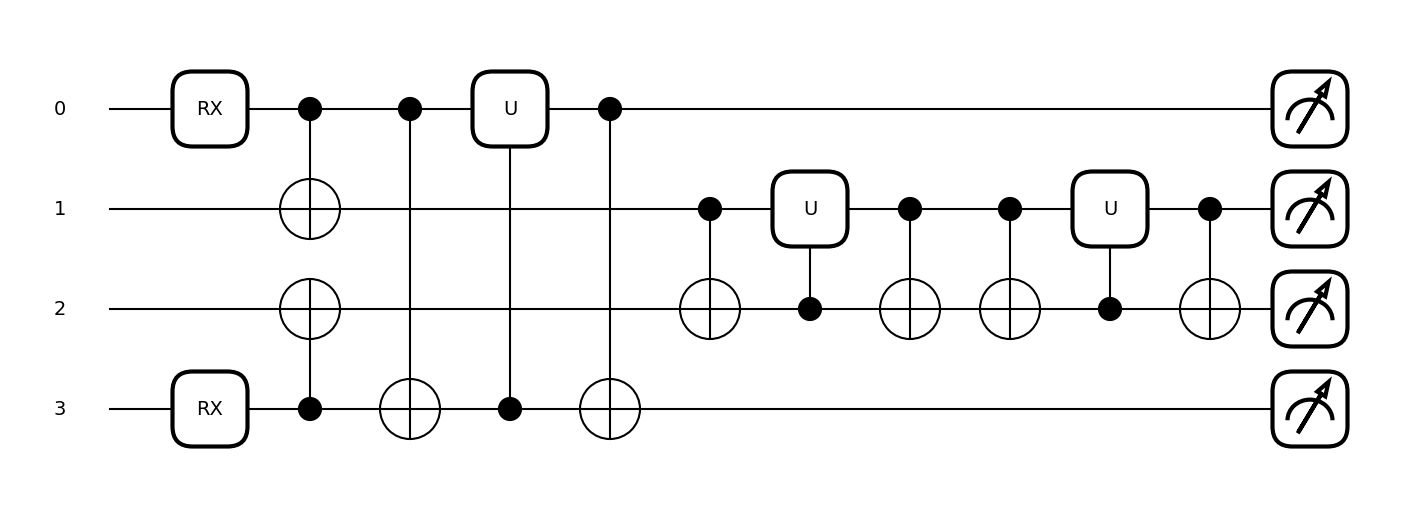

In [ ]:
import pennylane as qml
from pennylane import numpy as np

# Assuming you have angles alpha, beta, gamma, theta, and phi defined

dev = qml.device("default.qubit", wires=4)  # 4 qubits

@qml.qnode(dev)
def X_state(alpha, beta, gamma, theta, phi):
    qml.RX(alpha, wires=0)
    qml.CNOT(wires=[0, 1])
    qml.RX(beta, wires=3)
    qml.CNOT(wires=[3, 2])
    qml.CNOT(wires=[0, 3])
    qml.ControlledQubitUnitary([[1,0],[0,1]], control_wires=3, wires=0)
    qml.CNOT(wires=[0, 3])
    qml.CNOT(wires=[1, 2])
    qml.ControlledQubitUnitary([[1,0],[0,1]], control_wires=2, wires=1)
    qml.CNOT(wires=[1, 2])
    qml.CNOT(wires=[1, 2])
    qml.ControlledQubitUnitary([[1,0],[0,1]],control_wires=2, wires=1)
    qml.CNOT(wires=[1, 2])
    return qml.state()

# Execute the circuit (replace with your actual angle values)
alpha, beta, gamma, theta, phi=np.pi/4,1,1,1,1
result =X_state(alpha, beta, gamma, theta, phi)
rho=Qobj(np.outer(result,np.conjugate(result)),dims=cnot(4,0,1).dims)
print(ptrace(rho,[2,3]))
qml.draw_mpl(X_state)(1,1,1,1,1)

In [ ]:
from qiskit.circuit import QuantumCircuit, Parameter

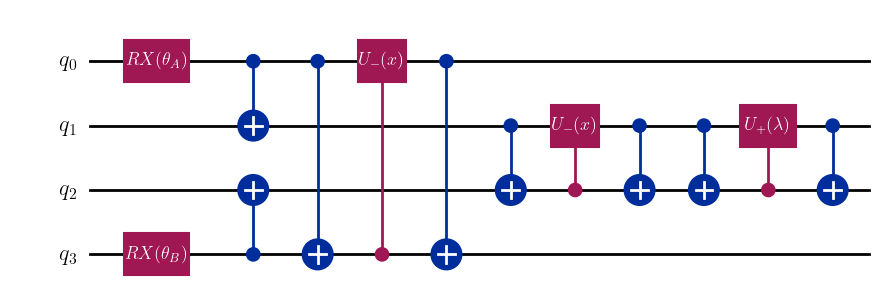

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import CPhaseGate
import numpy as np
import matplotlib.pyplot as plt

def pennylane_to_qiskit():
    """Converte o circuito PennyLane para Qiskit."""
    qr = QuantumRegister(4, 'q')
    qc = QuantumCircuit(qr)
    gate = Operator([[1,0],[0,1]]).to_instruction()
    gate.label = r"$U_{-}(x)$"
    cgate = gate.control()
    # Exemplo de uso:
    theta_A = Parameter('')
    gate1 = Operator([[1,0],[0,1]]).to_instruction()
    gate1.label = r"$U_{+}(\lambda)$"
    cgate1 = gate1.control()
    qc.rx(theta_A, qr[0],label=r'$RX(\theta_{A})$')
    qc.rx(theta_A, qr[3],label=r'$RX(\theta_{B})$')
    qc.cx(qr[0], qr[1])
    qc.cx(qr[3], qr[2])
    qc.barrier()

    qc.cx(qr[0], qr[3])
    qc.append(cgate, [qr[3] , qr[0]])  # Controlled-Phase gate with phase 0 (equivalent to controlled-I)
    qc.cx(qr[0], qr[3])
    qc.barrier()

    qc.cx(qr[1], qr[2])
    qc.append(cgate, [qr[2] , qr[1]])   # Controlled-Phase gate with phase 0 (equivalent to controlled-I)
    qc.cx(qr[1], qr[2])
    qc.barrier()

    qc.cx(qr[1], qr[2])
    qc.append(cgate1, [qr[2] , qr[1]]) # Controlled-Phase gate with phase 0 (equivalent to controlled-I)
    qc.cx(qr[1], qr[2])

    return qc

# Exemplo de uso:
theta_A = Parameter('')


qiskit_circuit = pennylane_to_qiskit()

# Desenha o circuito usando Matplotlib
qiskit_circuit.draw(output='mpl', plot_barriers=False)


## Resultados

(<Figure size 700x900 with 1 Axes>, <Axes: >)

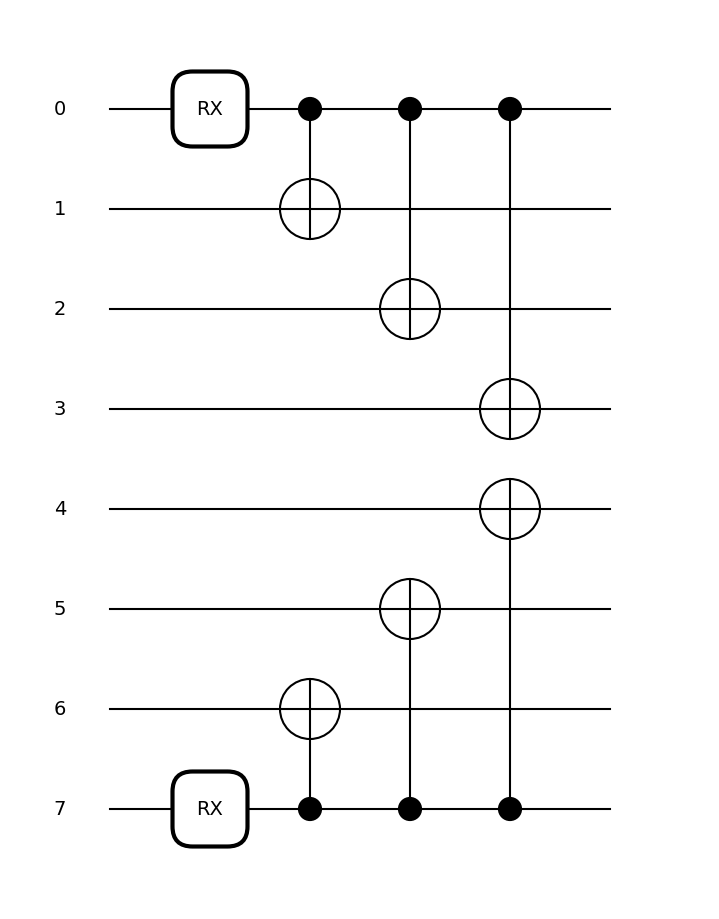

In [ ]:
num_qubits = 8
dev = qml.device("default.qubit", wires=4)  # 4 qubits

def termalization(num_qubits,theta_A,theta_B,x=0.5):
  qml.RX(theta_A, wires=0)
  qml.RX(theta_B, wires=num_qubits-1)

  #caixa termalizado
  for i in range(1,int(num_qubits/2)):
    qml.CNOT(wires=[0, i])
    qml.CNOT(wires=[num_qubits-1,num_qubits-(i+1) ])


qml.draw_mpl(termalization)(num_qubits,1,1,1)

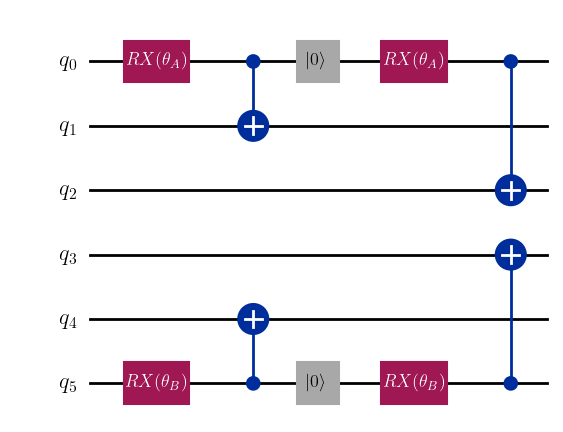

In [ ]:
from qiskit import QuantumCircuit
import numpy as np
import matplotlib.pyplot as plt

def thermalization_qiskit(num_qubits, theta_A, theta_B):
    """
    Cria um circuito de termalização no Qiskit.

    Args:
        num_qubits (int): Número total de qubits (deve ser par).
        theta_A (float): Ângulo de rotação RX no qubit 0.
        theta_B (float): Ângulo de rotação RX no qubit num_qubits-1.

    Returns:
        QuantumCircuit: O circuito de termalização criado.
    """

    qc = QuantumCircuit(num_qubits)
    theta_A=Parameter('')
    qc.rx(theta_A, 0,label=r'$RX(\theta_{A})$')
    qc.rx(theta_A, num_qubits - 1,label=r'$RX(\theta_{B})$')

    for i in range(1, int(num_qubits / 2)):
        if i>1:
          qc.reset(num_qubits - 1)
          qc.reset(0)
          qc.rx(theta_A, 0,label=r'$RX(\theta_{A})$')
          qc.rx(theta_A, num_qubits - 1,label=r'$RX(\theta_{B})$')
        qc.cx(0, i)
        qc.cx(num_qubits - 1, num_qubits - (i + 1))

    return qc

# Exemplo de uso:
num_qubits = 6
theta_A = np.pi / 4
theta_B = np.pi / 2

circuit = thermalization_qiskit(num_qubits, theta_A, theta_B)

# Desenha o circuito usando Matplotlib


circuit.draw(output='mpl')



(<Figure size 900x500 with 1 Axes>, <Axes: >)

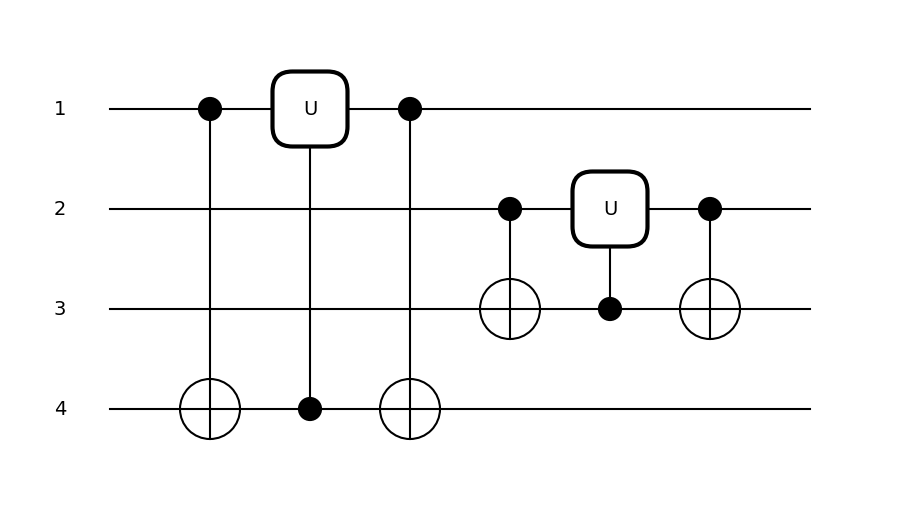

In [ ]:
num_qubits = 6
def u_minus1(x):
    # Calculate the components
    term1 = 1 * np.sqrt(1 - x) * qeye(2)
    term2 = (1j * np.sqrt(x)) * qt.sigmay()
    u_minus = term1 - term2
    return np.array((u_minus).full())
def correlacao(num_qubits,theta_A,theta_B,x=0.5):
  for i in range(1,int(num_qubits/2)):
      j=i
      qml.CNOT(wires=[i,num_qubits-(j+1)])
      qml.ControlledQubitUnitary(u_minus1(x), control_wires=[num_qubits-(j+1)], wires=[i])
      qml.CNOT(wires=[i,num_qubits-(j+1)])
qml.draw_mpl(correlacao)(num_qubits,1,1,1)

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Operator
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt

def u_minus1(x):
    """Calcula a matriz U-."""
    sigma_y = np.array([[0, -1j], [1j, 0]])
    term1 = np.sqrt(1 - x) * np.eye(2)
    term2 = 1j * np.sqrt(x) * sigma_y
    u_minus = term1 - term2
    return u_minus

def correlacao_qiskit(num_qubits, x=0.5):
    """Cria o circuito de correlação no Qiskit."""
    qc = QuantumCircuit(num_qubits)
    a=Parameter('')
    for i in range(1, int(num_qubits / 2)):
        j = i
        qc.cx(i, num_qubits - (i + 1))
        #u_minus_matrix = u_minus1(x)

        qc.cu(a,a,a,a,num_qubits - (i + 1),i,label=r"$U_{-}$") #utilizando control_qubits para adicionar o controle.
        qc.cx(i, num_qubits - (i + 1))
    return qc

# Exemplo de uso:
num_qubits = 6
x = 0.5

circuit = correlacao_qiskit(num_qubits, x)

# Desenha o circuito usando Matplotlib
circuit.draw(output='mpl',style=my_gate_names,justify='none')

NameError: name 'my_gate_names' is not defined

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt
from qiskit.visualization import circuit_drawer

def u_minus1(x):
    """Calcula a matriz U-."""
    sigma_y = np.array([[0, -1j], [1j, 0]])
    term1 = np.sqrt(1 - x) * np.eye(2)
    term2 = 1j * np.sqrt(x) * sigma_y
    u_minus = term1 - term2
    return np.real(u_minus)

def correlacao_qiskit(num_qubits, x=0.5):
    """Cria o circuito de correlação no Qiskit."""
    qc = QuantumCircuit(num_qubits)

    for i in range(1, int(num_qubits / 2)):
        j = i
        qc.cx(i, num_qubits - (i + 1))

        u_minus_matrix = u_minus1(x)

        # Cria um parâmetro para cada elemento da matriz U-
        params = [Parameter(f'u_{row}_{col}') for row in range(2) for col in range(2)]

        # Define a porta customizada U-
        qc.unitary(np.array([[1,0], [0, 1]]), num_qubits - (i + 1), label=r"$U_{-}$")

        # Define os parâmetros da porta customizada com os valores calculados
        param_dict = {1: u_minus_matrix[0, 0],
                      0: u_minus_matrix[0, 1],
                      0: u_minus_matrix[1, 0],
                      -1: u_minus_matrix[1, 1]}

        # Usa assign_parameters para atribuir os valores à porta
        #qc = qc.assign_parameters(param_dict)

        qc.cx(i, num_qubits - (i + 1))
    return qc

# Exemplo de uso:
num_qubits = 6
x = 0.5

circuit = correlacao_qiskit(num_qubits, x)

# Desenha o circuito usando Matplotlib
circuit.draw(output='mpl', justify='none')
plt.show()

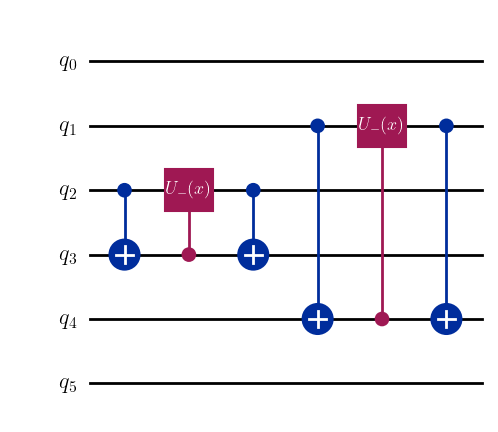

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Operator
import numpy as np
from scipy.linalg import expm
import matplotlib.pyplot as plt

def u_minus1(x):
    """Calcula a matriz U-."""
    sigma_y = np.array([[0, -1j], [1j, 0]])
    term1 = np.sqrt(1 - x) * np.eye(2)
    term2 = 1j * np.sqrt(x) * sigma_y
    u_minus = term1 - term2
    return u_minus

def correlacao_qiskit(num_qubits, x=0.5):
    """Cria o circuito de correlação no Qiskit."""
    gate = Operator([[1,0],[0,1]]).to_instruction()
    gate.label = r"$U_{-}(x)$"
    cgate = gate.control()
    qc = QuantumCircuit(num_qubits)

    for i in range(1, int(num_qubits / 2)):
        j = i
        qc.cx(i, num_qubits - (j + 1))
        u_minus_matrix = u_minus1(x)
        # Create a controlled gate from the unitary matrix
        qc.append(cgate, [num_qubits - (j + 1),i])

        qc.cx(i, num_qubits - (j + 1))

    return qc

# Exemplo de uso:
num_qubits = 6
x = 0.5

circuit = correlacao_qiskit(num_qubits, x)

# Desenha o circuito usando Matplotlib
circuit.draw(output='mpl',justify='none')


#rint(circuit.draw(output='text')) #imprime o circuito no terminal.

(<Figure size 900x500 with 1 Axes>, <Axes: >)

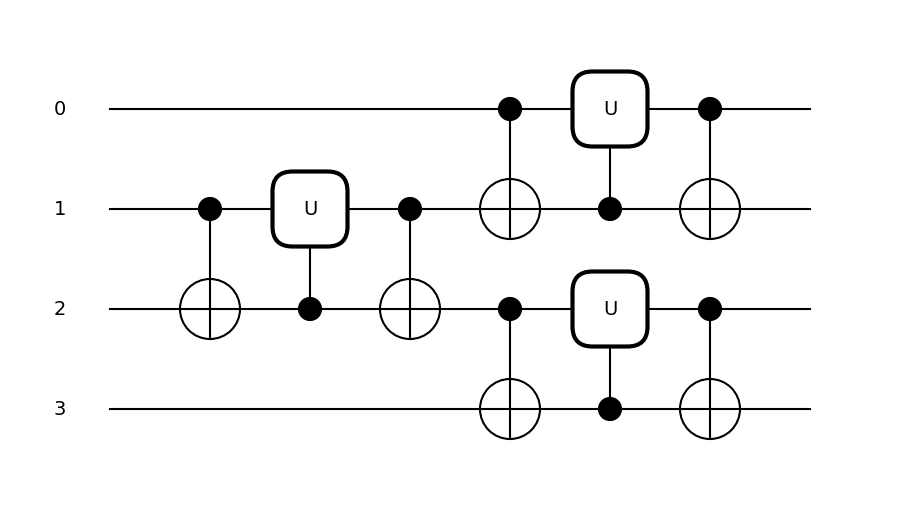

In [ ]:
num_qubits = 4
def u_minus1(x):
    # Calculate the components
    term1 = 1 * np.sqrt(1 - x) * qeye(2)
    term2 = (1j * np.sqrt(x)) * qt.sigmay()
    u_minus = term1 - term2
    return np.array((u_minus).full())

def correlacao2(num_qubits,theta_A,theta_B,x=0.5):
    qml.CNOT(wires=[1,2])
    qml.ControlledQubitUnitary(u_minus1(x), control_wires=[2], wires=[1])
    qml.CNOT(wires=[1,2])
    qml.CNOT(wires=[0,1])
    qml.ControlledQubitUnitary(u_minus1(x), control_wires=[1], wires=[0])
    qml.CNOT(wires=[0,1])
    qml.CNOT(wires=[2,3])
    qml.ControlledQubitUnitary(u_minus1(x), control_wires=[3], wires=[2])
    qml.CNOT(wires=[2,3])
qml.draw_mpl(correlacao2)(num_qubits,1,1,1)

<ipython-input-5-47251d49786c>:114: ComplexWarning: Casting complex values to real discards the imaginary part
  params[j] -= learning_rate * gradient


Epoch 1, Loss: (-0.25228528875472694+0j)
Epoch 2, Loss: (-0.2781860139974717+0j)
Epoch 3, Loss: (-0.30974545083989574+0j)
Epoch 4, Loss: (-0.34716284867055913+0j)
Epoch 5, Loss: (-0.3900829156917121+0j)
Epoch 6, Loss: (-0.43743986197686824+0j)
Epoch 7, Loss: (-0.487440609721043+0j)
Epoch 8, Loss: (-0.5377588142325443+0j)
Epoch 9, Loss: (-0.5859280982241238+0j)
Epoch 10, Loss: (-0.6298120253005168+0j)
Epoch 11, Loss: (-0.6679716090333654+0j)
Epoch 12, Loss: (-0.6998030656313015+0j)
Epoch 13, Loss: (-0.7254415616170921+0j)
Epoch 14, Loss: (-0.745526800116328+0j)
Epoch 15, Loss: (-0.7609472023789619+0j)
Epoch 16, Loss: (-0.7726389560894197+0j)
Epoch 17, Loss: (-0.7814631817800272+0j)
Epoch 18, Loss: (-0.7881501596913616+0j)
Epoch 19, Loss: (-0.7932879178591765+0j)
Epoch 20, Loss: (-0.7973344628328793+0j)
Epoch 21, Loss: (-0.8006394512566339+0j)
Epoch 22, Loss: (-0.8034672547300967+0j)
Epoch 23, Loss: (-0.806017641534871+0j)
Epoch 24, Loss: (-0.8084427814428247+0j)
Epoch 25, Loss: (-0.8108

/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


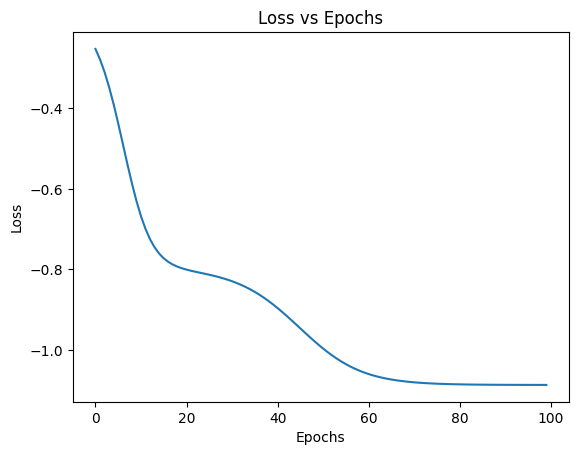

(<Figure size 500x300 with 1 Axes>, <Axes: >)

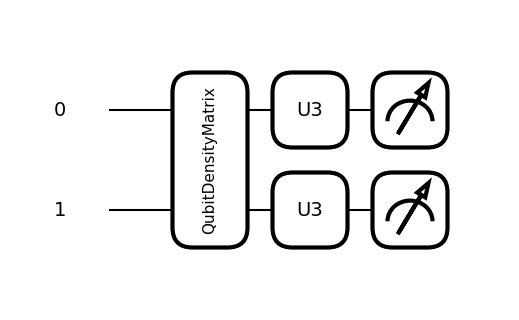

In [ ]:
num_qubits = 2

dev2 = qml.device("default.mixed", wires=num_qubits)

@qml.qnode(dev2)
def circuit(x,rho):
  qml.QubitDensityMatrix(rho.full(), wires=[0,1])
  qml.U3(x[0],x[1],x[2], wires=0)
  qml.U3(x[3],x[4],x[5], wires=1)
  return qml.state()
  #otimização

import numpy as np
num_qubits = 4
dev1 = qml.device("default.qubit", wires=num_qubits)

@qml.qnode(dev1)
def term_state(num_qubits,theta_A, theta_B):
    qml.RX(theta_A, wires=0)
    qml.RX(theta_B, wires=num_qubits-1)
    for i in range(1,int(num_qubits/2)):
      qml.CNOT(wires=[0, i])
      qml.CNOT(wires=[num_qubits-1,num_qubits-(i+1) ])
    return qml.state()

@qml.qnode(dev1)
def circuito(x):
    for i in range(0,int(num_qubits/2)):
      qml.CNOT(wires=[i,num_qubits-(i+1)])
      qml.ControlledQubitUnitary(u_minus1(x[i]), control_wires=[num_qubits-(i+1)], wires=[i])
      qml.CNOT(wires=[i,num_qubits-(i+1)])
    return qml.state()




def loss1(rho0,rhof,H):
    #loss para aumentar o trabalho
    return ((rhof-rho0)*H).tr()

def rhoarhob(epsilon_b,beta_a=1, epsilon_a=1, beta_b=2):
    #hamiltoniana
    sz=np.array([[1, 0], [0, -1]])
    H_A = -0.5 * epsilon_a * sz
    H_B = -0.5 * epsilon_b * sz

    # traço
    Z_a = np.trace(expm(-beta_a * H_A))
    Z_b = np.trace(expm(-beta_b * H_B))

    pa, pb, alpha=np.exp(-beta_a*epsilon_a)/Z_a,np.exp(-beta_b*epsilon_b)/Z_b,1/(Z_a*Z_b)

    element_00 = pa * pb - alpha**2
    element_11 = alpha**2 + pa * (1-pb)
    element_22 = alpha**2 +pb*(1-pa)
    element_33 = (1 - pa) * (1 - pb) - alpha**2

    matrix = np.array([
        [element_00, 0, 0, 0],
        [0, element_11, alpha, 0],
        [0, alpha, element_22, 0],
        [0, 0, 0, element_33]
    ])

    return qt.Qobj(matrix,dims=[[2,2],[2,2]])

def loss_function(params):
    """
    Função de perda a ser minimizada.
    Substitua por sua própria função de perda.
    """
    num_qubits = 2
    #rho_ab
    eb=0.5
    rho = rhoarhob(eb,2)
    #psi_ab
    parametros = params # Valores de exemplo para os parâmetros
    state = Qobj(circuit(parametros,rho),dims=cnot(num_qubits,0,1).dims)
    #função
    rho0 = rho # Operador densidade inicial
    rhof = state*state.dag()# operador densidade final
    H=tensor(-sigmaz()*0.5,qeye(2))+tensor(qeye(2),-sigmaz()*0.5*eb)

    return loss1(rho0,rhof,H)

def parameter_shift_gradient(params, j):
    """
    Calcula o gradiente da função de perda em relação ao parâmetro j
    usando a regra parameter-shift.
    """
    epsilon=0.05
    shifted_params_plus = params.copy()
    shifted_params_plus[j] += epsilon

    shifted_params_minus = params.copy()
    shifted_params_minus[j] -= epsilon

    gradient = (loss_function(shifted_params_plus) - loss_function(shifted_params_minus))/(2*epsilon)
    #print(gradient,loss_function(shifted_params_plus),loss_function(shifted_params_minus))
    return gradient

def stochastic_gradient_descent(params, learning_rate, num_epochs,epsilon):
    """
    Executa o algoritmo SGD usando a regra parameter-shift para calcular gradientes.
    """
    epoch=0
    loss=0
    loss_vec=[]
    epochs_vec=[]
    while ( epoch<num_epochs):#np.real(loss)>(-epsilon) and

      for j in range(len(params)):
          gradient = parameter_shift_gradient(params, j)
          params[j] -= learning_rate * gradient

      # Avalie a função de perda após cada época, se desejar
      loss = loss_function(params)
      loss_vec.append(loss)
      epochs_vec.append(epoch)
      print(f"Epoch {epoch+1}, Loss: {loss}")
      epoch+=1
    return params,loss_vec,epochs_vec

# Exemplo de uso
params = np.random.rand(6)  # Inicialize os parâmetros aleatoriamente
learning_rate = 0.5
num_epochs = 100

optimized_params,vec1,vec2 = stochastic_gradient_descent(params, learning_rate,num_epochs,0.1)
print(optimized_params)

plt.plot(vec2,vec1)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.show()
qml.draw_mpl(circuit)(optimized_params,rhoarhob(0.5))

Epoch 1, Loss: (-0.18455471353801572+0j)
Epoch 2, Loss: (-0.18501327450323127+0j)
Epoch 3, Loss: (-0.1854904919379822+0j)
Epoch 4, Loss: (-0.18598666561418475+0j)
Epoch 5, Loss: (-0.1865020521747075+0j)
Epoch 6, Loss: (-0.1870368601980428+0j)
Epoch 7, Loss: (-0.1875912452144916+0j)
Epoch 8, Loss: (-0.18816530473040033+0j)
Epoch 9, Loss: (-0.1887590733239318+0j)
Epoch 10, Loss: (-0.18937251788238105+0j)
Epoch 11, Loss: (-0.19000553305692042+0j)
Epoch 12, Loss: (-0.19065793701561304+0j)
Epoch 13, Loss: (-0.19132946757929437+0j)
Epoch 14, Loss: (-0.19201977882721255+0j)
Epoch 15, Loss: (-0.19272843825987263+0j)
Epoch 16, Loss: (-0.19345492460510247+0j)
Epoch 17, Loss: (-0.19419862634974047+0j)
Epoch 18, Loss: (-0.19495884107338168+0j)
Epoch 19, Loss: (-0.19573477565221686+0j)
Epoch 20, Loss: (-0.1965255473901455+0j)
Epoch 21, Loss: (-0.19733018612111794+0j)
Epoch 22, Loss: (-0.19814763731123716+0j)
Epoch 23, Loss: (-0.1989767661718039+0j)
Epoch 24, Loss: (-0.1998163627755978+0j)
Epoch 25,

/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


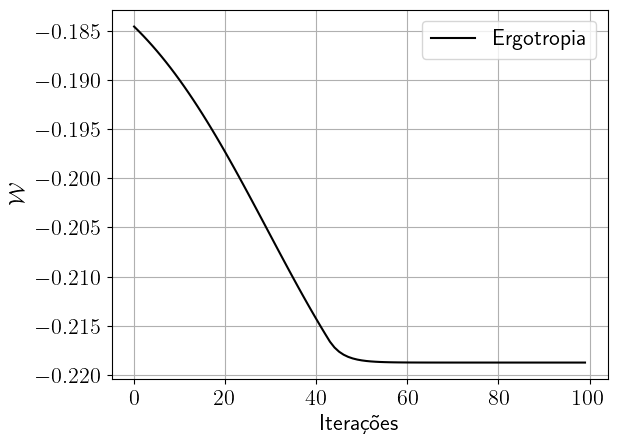

(<Figure size 700x300 with 1 Axes>, <Axes: >)

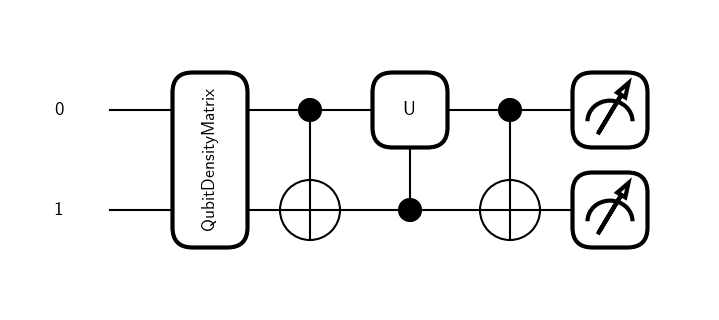

In [ ]:
num_qubits = 2

dev2 = qml.device("default.mixed", wires=num_qubits)

@qml.qnode(dev2)
def circuit(x,rho):
  qml.QubitDensityMatrix(rho.full(), wires=[0,1])
  qml.U3(x[0],x[1],x[2], wires=0)
  qml.U3(x[3],x[4],x[5], wires=1)
  return qml.state()
  #otimização

import numpy as np
num_qubits = 4
dev1 = qml.device("default.qubit", wires=num_qubits)

def u_minus1(x):
    # Calculate the components
    term1 = 1 * np.sqrt(1 - x) * qeye(2)
    term2 = (1j * np.sqrt(x)) * qt.sigmay()
    u_minus = term1 - term2
    return np.array((u_minus).full())

@qml.qnode(dev1)
def term_state(num_qubits,theta_A, theta_B):
    qml.RX(theta_A, wires=0)
    qml.RX(theta_B, wires=num_qubits-1)
    for i in range(1,int(num_qubits/2)):
      qml.CNOT(wires=[0, i])
      qml.CNOT(wires=[num_qubits-1,num_qubits-(i+1) ])
    return qml.state()

@qml.qnode(dev2)
def circuito(x,rho):
    qml.QubitDensityMatrix(rho.full(), wires=[0,1])
    qml.CNOT(wires=[0,1])
    qml.ControlledQubitUnitary(u_minus1(np.sin(x[0])**2), control_wires=[1], wires=[0])
    qml.CNOT(wires=[0,1])
    return qml.state()




def loss1(rho0,rhof,H):
    #loss para aumentar o trabalho
    return ((rhof-rho0)*H).tr()

def rhoarhob(epsilon_b,beta_a=1, epsilon_a=1, beta_b=2):
    #hamiltoniana
    sz=np.array([[1, 0], [0, -1]])
    H_A = -0.5 * epsilon_a * sz
    H_B = -0.5 * epsilon_b * sz

    # traço
    Z_a = np.trace(expm(-beta_a * H_A))
    Z_b = np.trace(expm(-beta_b * H_B))

    pa, pb, alpha=np.exp(-beta_a*epsilon_a/2)/Z_a,np.exp(-beta_b*epsilon_b/2)/Z_b,1/(Z_a*Z_b)

    element_00 = pa * pb - alpha**2
    element_11 = alpha**2 + pa * (1-pb)
    element_22 = alpha**2 + pb*(1-pa)
    element_33 = (1 - pa) * (1 - pb) - alpha**2

    matrix = np.array([
        [element_00, 0, 0, 0],
        [0, element_11, alpha, 0],
        [0, alpha, element_22, 0],
        [0, 0, 0, element_33]
    ])

    return qt.Qobj(matrix,dims=[[2,2],[2,2]])

def loss_function(params):
    """
    Função de perda a ser minimizada.
    Substitua por sua própria função de perda.
    """
    num_qubits = 2
    #rho_ab
    eb=0.5
    rho = rhoarhob(eb,2)
    #psi_ab
    parametros = params # Valores de exemplo para os parâmetros
    state = Qobj(circuito(parametros,rho),dims=cnot(num_qubits,0,1).dims)
    #função
    rho0 = rho # Operador densidade inicial
    rhof = state*state.dag()# operador densidade final
    H=tensor(-sigmaz()*0.5,qeye(2))+tensor(qeye(2),-sigmaz()*0.5*eb)

    return loss1(rho0,rhof,H)

def parameter_shift_gradient(params, j):
    """
    Calcula o gradiente da função de perda em relação ao parâmetro j
    usando a regra parameter-shift.
    """
    epsilon=0.05
    shifted_params_plus = params.copy()
    shifted_params_plus[j] += epsilon

    shifted_params_minus = params.copy()
    shifted_params_minus[j] -= epsilon

    gradient = (loss_function(shifted_params_plus) - loss_function(shifted_params_minus))/(2*epsilon)
    #print(gradient,loss_function(shifted_params_plus),loss_function(shifted_params_minus))
    return np.real(gradient)

def stochastic_gradient_descent(params, learning_rate, num_epochs,epsilon):
    """
    Executa o algoritmo SGD usando a regra parameter-shift para calcular gradientes.
    """
    epoch=0
    loss=0
    loss_vec=[]
    epochs_vec=[]
    while ( epoch<num_epochs):#np.real(loss)>(-epsilon) and

      for j in range(len(params)):
          gradient = parameter_shift_gradient(params, j)
          params[j] -= learning_rate * gradient

      # Avalie a função de perda após cada época, se desejar
      loss = loss_function(params)
      loss_vec.append(loss)
      epochs_vec.append(epoch)
      print(f"Epoch {epoch+1}, Loss: {loss}")
      epoch+=1
    return params,loss_vec,epochs_vec

# Exemplo de uso
params = np.random.rand(1)  # Inicialize os parâmetros aleatoriamente
learning_rate = 0.25
num_epochs = 100

optimized_params,vec1,vec2 = stochastic_gradient_descent(params, learning_rate,num_epochs,0.1)
print(optimized_params)

plt.plot(vec2,vec1,label='Ergotropia',color='black')
plt.xlabel('Iterações')
plt.ylabel('$\\mathcal{W}$')
plt.legend()
plt.grid()
#plt.title('Ergotropia')
plt.show()
qml.draw_mpl(circuito)(optimized_params,rhoarhob(0.5))

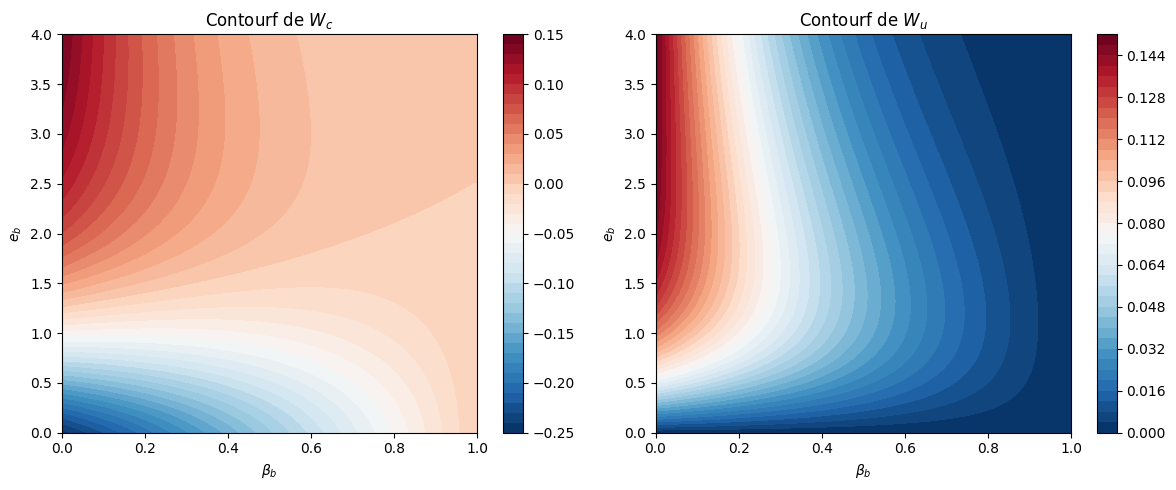

In [ ]:
import numpy as np

def calcular_wc(eb, ea, beta_b, beta_a, lamb):
  """
  Calcula <Wc> usando a fórmula fornecida.

  Args:
    eb: Valor de eb (float).
    ea: Valor de ea (float).
    beta_b: Valor de beta_b (float).
    beta_a: Valor de beta_a (float).
    Za: Valor de Za (float).
    Zb: Valor de Zb (float).
    lamb: Valor de lambda (float).
    alpha: Valor de alpha (float).

  Returns:
    O valor calculado de <Wc> (float).
  """

  sz=np.array([[1, 0], [0, -1]])

  H_A = -0.5 * ea * sz
  H_B = -0.5 * eb * sz

  # traço
  Za = np.trace(expm(-beta_a * H_A))
  Zb = np.trace(expm(-beta_b * H_B))

  alpha=1/(Za*Zb)

  numerador = np.sinh((eb * beta_b - ea * beta_a)*0.5)
  denominador = Za * Zb
  termo1 = numerador / denominador
  termo2 = 2 * alpha * np.sqrt(lamb * (1 - lamb))
  wc = (eb - ea) * (termo1 * lamb + termo2)
  return wc

def calcular_wu(eb, ea, beta_b, beta_a, lamb):
  """
  Calcula <Wu> usando a fórmula fornecida.

  Args:
    eb: Valor de eb (float).
    ea: Valor de ea (float).
    beta_b: Valor de beta_b (float).
    beta_a: Valor de beta_a (float).
    Za: Valor de Za (float).
    Zb: Valor de Zb (float).
    lamb: Valor de lambda (float).

  Returns:
    O valor calculado de <Wu> (float).
  """
  sz=np.array([[1, 0], [0, -1]])
  H_A = -0.5 * ea * sz
  H_B = -0.5 * eb * sz

  # traço
  Za = np.trace(expm(-beta_a * H_A))
  Zb = np.trace(expm(-beta_b * H_B))

  numerador = np.sinh((eb * beta_b - ea * beta_a)*0.5)
  denominador = Za * Zb
  wu = (eb - ea) * (numerador / denominador) * lamb
  return wu

# Exemplo de uso

lamb=0.6

wc=np.zeros((101,101))
wu=np.zeros((101,101))

ebs=np.linspace(0,1,101)
bbs=np.linspace(0,4,101)

for j,eb in enumerate(ebs):
  for k,bb in enumerate(bbs):
    ea=1
    ba=2*bb
    if (ea*ba-bb*eb)<0:
      print(ea*ba-bb*eb)
    wc[k][j] = calcular_wc(eb, ea, bb, ba,lamb)
    wu[k][j] = calcular_wu(eb, ea, bb, ba,lamb)

# Criando os contour plots preenchidos (contourf)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
contour_wc = plt.contourf( ebs,bbs, wc, levels=40, cmap='RdBu_r')  # Inverteu bbs e ebs aqui
plt.colorbar(contour_wc)
plt.xlabel(r'$\beta_b$')
plt.ylabel(r'$e_b$')
plt.title(r'Contourf de $W_c$')

plt.subplot(1, 2, 2)
contour_wu = plt.contourf( ebs,bbs, wu, levels=40, cmap='RdBu_r')  # Inverteu bbs e ebs aqui
plt.colorbar(contour_wu)
plt.xlabel(r'$\beta_b$')
plt.ylabel(r'$e_b$')
plt.title(r'Contourf de $W_u$')

plt.tight_layout()
plt.show()

NameError: name 'minz' is not defined

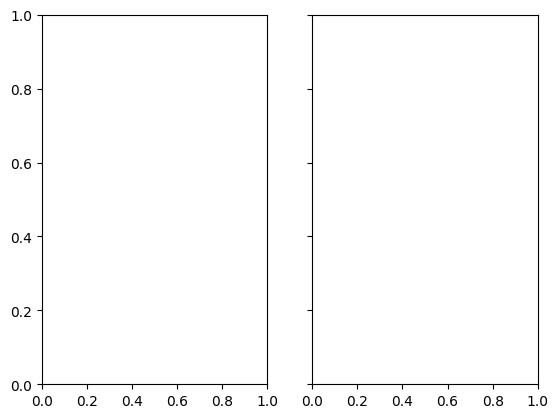

In [ ]:
fig,ax=plt.subplots(1,2,sharey='row')

cminmax = [minz,0.231]

clevs = [cminmax[0]+0.0,cminmax[1]+0.0]
clevs = [cminmax[0],-cminmax[0]]
cs1 = ax[0].contourf(X, Y, Zteo,40,vmin=clevs[0],vmax=clevs[1],cmap='RdBu_r')
ax[0].contour(cs1, levels=[0], colors='k',linestyles='dashed')

ax[0].set_title('Caso não correlacionado')
ax[0].set_xlabel(r'$\epsilon_B/\epsilon_A$',fontsize=20)
ax[0].set_ylabel(r'$\beta_B/\beta_A$',fontsize=20)

cs2 = ax[1].contourf(X, Y, Z, 40, vmin=clevs[0],vmax=clevs[1],cmap='RdBu_r')
ax[0].contour(cs2, levels=[0], colors='k',linestyles='dashed')
ax[1].set_title('Caso Correlacionado')
ax[1].set_xlabel(r'$\epsilon_B/\epsilon_A$',fontsize=20)

sm = plt.cm.ScalarMappable(cmap='RdBu_r')
#sm = plt.cm.ScalarMappable(cmap='bwr')
sm.set_clim(vmin=clevs[0], vmax=clevs[1])

#divider = make_axes_locatable(ax[1])
cbar_ax = fig.add_axes([0.93, 0.15, 0.03, 0.7])
fig.colorbar(sm,cax=cbar_ax)

### Analitico vs Simulação

In [ ]:
class QuantumCircuit:
    def __init__(self, num_qubits=2,eb=0.5,shot=1000,type_dev="default.mixed",backend_dev=None):
        #entrada de dados
        self.num_qubits = num_qubits
        self.shot=shot
        if shot==None:
          self.dev = qml.device(type_dev, wires=self.num_qubits)
        elif backend_dev==None:
          self.dev = qml.device(type_dev, wires=self.num_qubits,shots=shot)
        else:
          self.dev = qml.device(type_dev, wires=self.num_qubits,shots=shot,backend=backend_dev)
        self._phi_inicial =qml.QNode(self.__phi_inicial,self.dev)
        self._phi_final =qml.QNode(self.__phi_final,self.dev)
        self._caixa_SWAP =qml.QNode(self.__caixa_SWAP,self.dev)
        self._phi_entagled =qml.QNode(self.__phi_entagled,self.dev)
        self.eb=eb

    def thetas_c(self,bb=2,ea=1,ba=1):
    #parametro de correlação
      #parametros do sistema
      bb=bb*ba
      #hamiltoniana do sitema
      sz=np.array([[1, 0], [0, -1]])

      H_A=-0.5*ea*sz
      H_B=-0.5*self.eb*sz

      # Função partição
      Za = np.trace(expm(-ba * H_A))

      Zb = np.trace(expm(-bb * H_B))
      #operador densidade

      p_a=np.exp(ba*ea/2)/Za
      p_b=np.exp(bb*self.eb/2)/Zb
      #coeficiente

      a=1/(Za*Zb)

      pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

      pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

      x=((p_b-p_a)/(pp-pm)+1)*0.5
      #angulo para rotação x
      theta_a=2*np.arccos(np.sqrt(pp))
      theta_b=2*np.arccos(np.sqrt(pm))

      return theta_a,theta_b,x
    def u_minus1(self,x):
        # Calculate the components
        term1 = 1 * np.sqrt(1 - x) * qeye(2)
        term2 = (1j * np.sqrt(x)) * qt.sigmay()
        u_minus = term1 - term2
        return np.array((u_minus).full())

    def u_plus1(self,x):
        # Calculate the components

        term1 = 1 * np.sqrt(1 - x) * qeye(2)
        term2 = (1j * np.sqrt(x)) * qt.sigmay()
        u_minus = term1 + term2

        return np.array((u_minus).full())

    def __phi_entagled(self,theta_A,theta_B,x=0.5):
        qml.RX(theta_A, wires=0)
        qml.RX(theta_B, wires=self.num_qubits-1)

        #caixa termalizado
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[0, i])
          qml.CNOT(wires=[self.num_qubits-1,self.num_qubits-(i+1) ])

        #caixa correlação
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[i,self.num_qubits-(i+1)])
          qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[self.num_qubits-(i+1)], wires=[i])
          qml.CNOT(wires=[i,self.num_qubits-(i+1)])

        #conectar estados termalizados
        for i in range(1,int(self.num_qubits)-1):
          qml.CNOT(wires=[i,(i+1)])
          qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[(i+1)], wires=[i])
          qml.CNOT(wires=[i,(i+1)])

        return qml.state()

    def __phi_inicial(self,theta_A, theta_B,x=0.5):
        qml.RX(theta_A, wires=0)
        qml.RX(theta_B, wires=self.num_qubits-1)

        #caixa termalizado
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[0, i])
          qml.CNOT(wires=[self.num_qubits-1,self.num_qubits-(i+1) ])

        #caixa correlação
        for i in range(1,int(self.num_qubits/2)):
            j=i
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
            qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[self.num_qubits-(j+1)], wires=[i])
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
        #if self.shot==None:
         # return qml.state()
        if self.num_qubits==8:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3))*0.5-0.5*((qml.PauliZ(4)+qml.PauliZ(5)+qml.PauliZ(6))))
        elif self.num_qubits==10:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3)+qml.PauliZ(4))*0.5-0.5*((qml.PauliZ(5)+qml.PauliZ(6)+qml.PauliZ(7)+qml.PauliZ(8))))
        elif self.num_qubits==12:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3)+qml.PauliZ(4)+qml.PauliZ(5))*0.5-0.5*((qml.PauliZ(6)+qml.PauliZ(7)+qml.PauliZ(8)+qml.PauliZ(9)+qml.PauliZ(10))))
        elif self.num_qubits==6:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2))*0.5-0.5*((qml.PauliZ(3)+qml.PauliZ(4))))
        elif self.num_qubits==4:
          return qml.expval(-self.eb*(qml.PauliZ(1))*0.5-0.5*((qml.PauliZ(2))))


    def __phi_final(self,theta_A,theta_B,x=0.5):

        qml.RX(theta_A, wires=0)
        qml.RX(theta_B, wires=self.num_qubits-1)
        #caixa termalizado
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[0, i])
          qml.CNOT(wires=[self.num_qubits-1,self.num_qubits-(i+1) ])

        #caixa de correlação
        for i in range(1,int(self.num_qubits/2)):
          #for j in range(1,int(self.num_qubits/2)):
            j=i
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
            qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[self.num_qubits-(j+1)], wires=[i])
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])

        #caixa SWAP
        for i in range(1,int(self.num_qubits/2)):
          #for j in range(1,int(self.num_qubits/2)):
            j=i
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
            qml.ControlledQubitUnitary(self.u_plus1(x), control_wires=[self.num_qubits-(j+1)], wires=[i])
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
        #if self.shot==0:
         # return qml.state()
        if self.num_qubits==8:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3))*0.5-0.5*((qml.PauliZ(4)+qml.PauliZ(5)+qml.PauliZ(6))))
        elif self.num_qubits==10:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3)+qml.PauliZ(4))*0.5-0.5*((qml.PauliZ(5)+qml.PauliZ(6)+qml.PauliZ(7)+qml.PauliZ(8))))
        elif self.num_qubits==12:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3)+qml.PauliZ(4)+qml.PauliZ(5))*0.5-0.5*((qml.PauliZ(6)+qml.PauliZ(7)+qml.PauliZ(8)+qml.PauliZ(9)+qml.PauliZ(10))))
        elif self.num_qubits==6:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2))*0.5-0.5*((qml.PauliZ(3)+qml.PauliZ(4))))
        elif self.num_qubits==4:
          return qml.expval(-self.eb*(qml.PauliZ(1))*0.5-0.5*((qml.PauliZ(2))))


    def __caixa_SWAP(self,x,rho):
      #gerando uma lista com os fios
      wires_list=[]
      for i in range(self.num_qubits):
        wires_list.append(i)

      qml.QubitDensityMatrix(rho, wires=wires_list)
      #caixa swap
      for i in range(self.num_qubits):
        qml.U3(x[i+0],x[i+1],x[i+2], wires=i)

      return qml.state()

    def hamiltoniana(self,eb,ea=1):
      #gerando a matriz identidade para gerar os circuitos
      resultfi=Qobj(np.zeros([2**(self.num_qubits-2),2**(self.num_qubits-2)]),dims=(cnot(self.num_qubits-2,0,1).dims))
      inteiro=int((self.num_qubits)/2)
      #gerando o hamiltoniano para Num Qubits

      for i in range(1,self.num_qubits-1):
        result=Qobj(1)
        for j in range(1,self.num_qubits-1):
          if i==j and i<inteiro:
            result=tensor(result,-ea*qt.sigmaz()/2)

          elif i==j and i>=inteiro:
            result=tensor(result,-eb*qt.sigmaz()/2)

          else:
            result=tensor(result,qeye(2))

        resultfi=resultfi+Qobj(result,dims=cnot(self.num_qubits-2,0,1).dims)

      return resultfi

    #compilador
    def compiled_ibm(self,circuit):#tem que alterar
        compiled_circuit = qml.compile(circuit, pipeline=[
                partial(qml.transforms.commute_controlled, direction="left"), # Now partial is defined
                partial(qml.transforms.merge_rotations, atol=1e-6), # Now partial is defined
                qml.transforms.cancel_inverses
            ],basis_set=["CNOT", "SX", "RZ"],num_passes=4)
        return compiled_circuit

    # Métodos para acessar os circuitos phi_inicial e phi_final
    def get_phi_inicial(self):
        return self.__phi_inicial

    def get_phi_final(self):
        return self.__phi_final
    #truque para gerar a biblioteca do penny lane com POO
    def phi_inicial(self,theta_A, theta_B,x=0.5):
      return self._phi_inicial(theta_A, theta_B,x)

    def phi_entagled(self,theta_A, theta_B,x=0.5):
      return self._phi_entagled(theta_A, theta_B,x)

    def draw(self,function):#resposta temporaria
      qml.draw_mpl(function)(1,1,0.5)
      return

    def caixa_SWAP(self,x,rho):
      return self._caixa_SWAP(x,rho)

    def phi_final(self,theta_A,theta_B,x=0.5):
      return self._phi_final(theta_A,theta_B,x)

class MyGates:
  def __init__(self,num_qubits=2):
    pass
class QuantumOptimization:
    dev=None
    def __init__(self,rho,num_qubits=2,epsilon=0.05,eb=0.5):
        self.num_qubits = num_qubits
        self.epsilon=epsilon
        self.eb=eb
        self.rho=rho
        self.trace=np.linspace(1,num_qubits-2,num_qubits-2,dtype=int)
        self.quantum_circuit = QuantumCircuit(self.num_qubits)
        #self.dev = qml.device("default.mixed", wires=self.num_qubits)
        #self.circuit = qml.QNode(self.__circuit, self.dev)

    def loss1(self, rho0, rhof, H):
        #função custo baseado no trabalho
        return np.real(((qt.ptrace(rhof,self.trace) - qt.ptrace(rho0,self.trace)) * H).tr())

    def thetas_c(self,bb=2,ea=1,ba=1):
      #parametro de correlação
      #parametros do sistema
      bb=bb*ba
      #hamiltoniana do sitema
      sz=np.array([[1, 0], [0, -1]])

      H_A=-0.5*ea*sz
      H_B=-0.5*self.eb*sz

      # Função partição
      Za = np.trace(expm(-ba * H_A))

      Zb = np.trace(expm(-bb * H_B))
      #operador densidade

      p_a=np.exp(ba*ea/2)/Za
      p_b=np.exp(bb*self.eb/2)/Zb
      #coeficiente

      a=1/(Za*Zb)

      pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

      pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

      x=((p_b-p_a)/(pp-pm)+1)*0.5
      #angulo para rotação x
      theta_a=2*np.arccos(np.sqrt(pp))
      theta_b=2*np.arccos(np.sqrt(pm))

      return theta_a,theta_b,x

    def loss_function(self, params):
        #estado inicial
        rho=self.rho

        rho0 =  qt.Qobj(rho, dims=cnot(self.num_qubits, 0, 1).dims)

        #estado final
        rhof = qt.Qobj(self.quantum_circuit.caixa_SWAP(params, rho), dims=cnot(self.num_qubits, 0, 1).dims)
        H = self.quantum_circuit.hamiltoniana(eb)

        return self.loss1(rho0, rhof, H)

    def parameter_shift_gradient(self, params, j):
        # metod do gradiente
        epsilon = self.epsilon
        shifted_params_plus = params.copy()
        shifted_params_plus[j] += epsilon

        shifted_params_minus = params.copy()
        shifted_params_minus[j] -= epsilon

        gradient = (
            self.loss_function(shifted_params_plus)
            - self.loss_function(shifted_params_minus)
        ) / (2 * epsilon)
        return gradient


    def stochastic_gradient_descent(self, params, learning_rate, num_epochs):
        epoch = 0
        loss = 0
        loss_vec = []
        epochs_vec = []
        #otimizando parametros
        for _ in range(num_epochs):
            #otimização
            for j in range(len(params)):
                gradient = self.parameter_shift_gradient(params, j)
                params[j] -= learning_rate * np.real(gradient)

            loss = self.loss_function(params)
            loss_vec.append(loss)
            epochs_vec.append(epoch)
            epoch += 1
        return params, loss_vec[-1]

class Plots:
  def __init__(self):
    pass
  def plotar(self,x,y,labelx=None,labely=None):
    plt.plot(x,y,'.')
    plt.ylabel(labely)
    plt.xlabel(labelx)
    plt.grid(True)
    plt.show()

100%|██████████| 21/21 [00:07<00:00,  2.66it/s]


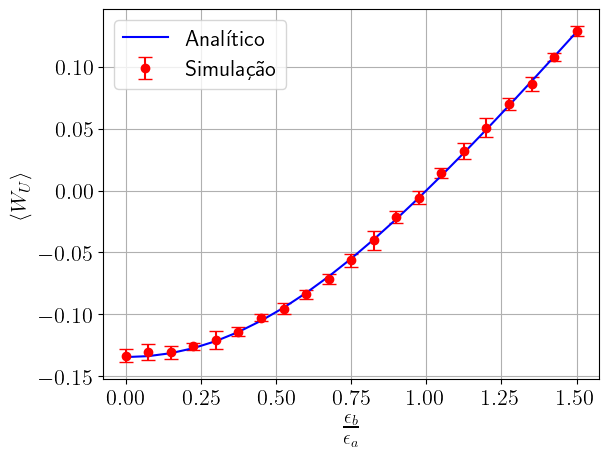

In [ ]:
num_qubits=4
n=21
ebs=np.linspace(0,1.5,n)
expval_med=np.linspace(0,1.5,n)
expval_var=np.linspace(0,1.5,n)
expval1=np.linspace(0,1.5,n)
expval2=np.linspace(0,1.5,n)
sum=[]
real=np.linspace(0,1.5,n)
plot=Plots()
for i,eb in enumerate(tqdm(ebs)):
  Quan6=QuantumCircuit(num_qubits,eb,20000)
  theta_a,theta_b,x=Quan6.thetas_c()

  for j in range(10):#fazendo média
    expval1=Quan6.phi_inicial(theta_a,theta_b,x)
    expval2=Quan6.phi_final(theta_a,theta_b,x)
    sum.append(-expval2+expval1)

  Quan7=QuantumCircuit(num_qubits,eb,shot=None)
  theta_a,theta_b,x=Quan7.thetas_c()
  real[i]=(-Quan7.phi_final(theta_a,theta_b,x)+Quan7.phi_inicial(theta_a,theta_b,x))
  #print(-Quan7.phi_final(theta_a,theta_b,x)+Quan7.phi_inicial(theta_a,theta_b,x))
  expval_med[i]=np.mean(sum)
  expval_var[i]=np.std(sum)
  sum=[]
plt.errorbar(ebs,expval_med,expval_var, fmt='o', capsize=5,label='Simulação',color='r')
plt.plot(ebs,real,label='Analítico',color='b')
plt.ylabel('$\\langle W_{U} \\rangle $')
plt.xlabel('$ \\frac{\\epsilon_{b}}{\\epsilon_{a}}$',fontsize=20)
plt.legend()
plt.grid(True)
plt.show()

### Multiplos qubits

In [ ]:
import matplotlib.pyplot as plt
font = {
        'weight' : 'bold',
        'size'   : 16}
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.rc('font', **font)

def thetas_u(e,b,ea=1,ba=1):
 #parametro de correlação
  #parametros do sistema
  bb=b*ba
  eb=e*ea
  #hamiltoniana do sitema
  sz=np.array([[1, 0], [0, -1]])

  H_A=-0.5*ea*sz
  H_B=-0.5*eb*sz

  # Função partição
  Za = np.trace(expm(-ba * H_A))

  Zb = np.trace(expm(-bb * H_B))
  #operador densidade

  p_a=np.exp(ba*ea/2)/Za
  p_b=np.exp(bb*eb/2)/Zb
  #coeficiente

  pm=0.5*(p_a+p_b+abs(p_b-p_a))

  pp=0.5*(p_a+p_b-abs(p_b-p_a))

  x=0 # é escrito como x=((pb-pa)/(pb-pa)+1)/2=1, já que o alpha = 0 evita problema computacional

  #angulo para rotação x
  theta_a=2*np.arccos(np.sqrt(pp))
  theta_b=2*np.arccos(np.sqrt(pm))

  return theta_a,theta_b,x
def control_target(control,target,num_bits,U):
  # Define projectors for the control qubit
  P0 = qt.basis(2, 0) * qt.basis(2, 0).dag()  # Projector onto the |0> state
  P1 = qt.basis(2, 1) * qt.basis(2, 1).dag()  # Projector onto the |1> state
  #criando qobj
  C0 =qt.Qobj(1)
  C1 =qt.Qobj(1)
  #criando gate com controle e alvo
  for i in range(num_bits):
    #criando operação no alvo
    if target==i:

      C0=tensor(C0,qeye(2))
      C1=tensor(C1,U)
    #escolhendo o controle
    elif control==i:

      C0=tensor(C0,P0)
      C1=tensor(C1,P1)

    else:

      C0=tensor(C0,qeye(2))
      C1=tensor(C1,qeye(2))
  return np.array((C0+C1).full())

def u_plus(x):
    term1 = 1 * np.sqrt(1 - x) * qeye(2)
    term2 = (1j * np.sqrt(x)) * qt.sigmay()
    u_minus = term1 + term2
    return u_minus


def u_minus(x):
    # Calculate the components
    term1 = 1 * np.sqrt(1 - x) * qeye(2)
    term2 = (1j * np.sqrt(x)) * qt.sigmay()
    u_minus = term1 - term2
    return u_minus
def cnot_gate(control, target, num_qubits):
    return np.array(cnot(N=num_qubits,control=control, target=target).full())

def cnots_n(n_qubits):
    #gerando o tamanho dos dois cnots
    inteiro=int(n_qubits/2)
    cn_quan=Qobj(qeye(2**n_qubits),dims=(cnot(n_qubits,0,1).dims))
    #gerando cnot generalizado
    for i in range(1,inteiro):

      flag=tensor(cnot(inteiro,0,i),cnot(inteiro,inteiro-1,inteiro-(i+1)))
      cn_quan=cn_quan*flag
    return cn_quan

def box_correlation(num_qubits,control,target,x):

    circuit =cnot_gate(control, target, num_qubits)@control_target(target,control,num_qubits,u_minus(x))@cnot_gate(control, target, num_qubits)

    return circuit

def box_par_swap(num_qubits,control,target,x):

    circuit =cnot_gate(control, target, num_qubits)@control_target(target,control,num_qubits,u_plus(x))@cnot_gate(control, target, num_qubits)

    return circuit
def boxs_correlation(num_qubits,x):

    #gerando a matriz identidade para gerar os circuitos
    result=Qobj(qeye(2**num_qubits),dims=(cnot(num_qubits,0,3).dims))
    inteiro=int(num_qubits/2)

    #multiplicando as portas lógicas
    for i in range(inteiro):
      result=result*Qobj(box_correlation(num_qubits,(inteiro-(i+1)),(inteiro+i),x),dims=(cnot(num_qubits,0,1).dims))
    return result

def hamiltoniana(eb,ea=1,num_qubits=4):
  #gerando a matriz identidade para gerar os circuitos
  resultfi=Qobj(qeye(2**(num_qubits-2)),dims=(cnot(num_qubits-2,0,1).dims))
  inteiro=int((num_qubits)/2)
  #gerando o hamiltoniano
  for i in range(1,num_qubits-1):
    result1=Qobj(1)
    for j in range(1,num_qubits-1):
      if i==j and i<inteiro:
        result1=tensor(result1,-ea*qt.sigmaz()/2)
      elif i==j and i>=inteiro:
        result1=tensor(result1,-eb*qt.sigmaz()/2)
      else:
        result1=tensor(result1,qeye(2))
    resultfi=resultfi+Qobj(result1,dims=cnot(num_qubits-2,0,1).dims)
  return resultfi

#hamiltoniana para calcular calor A
def hamiltoniana_a(eb,ea=1,num_qubits=4):
  #gerando a matriz identidade para gerar os circuitos
  if int((num_qubits-2)/2)>1:
    resultfi=Qobj(qeye(2**(int((num_qubits-2)/2))),dims=(cnot(int((num_qubits-2)/2),0,1).dims))
  else:
    return -ea*qt.sigmaz()/2
  inteiro=int((num_qubits)/2)
  #gerando o hamiltoniano
  for i in range(1,int((num_qubits-2)/2+1)):
    result1=Qobj(1)
    result2=Qobj(1)
    for j in range(1,int((num_qubits)/2)+1):
      if i==j and i<inteiro:
        result1=tensor(result1,-ea*qt.sigmaz()/2)
        result2=tensor(result2,qeye(2))
      else:
        result1=tensor(result1,qeye(2))
        result2=tensor(result2,qeye(2))
    resultfi=resultfi+Qobj(result1+result2,dims=cnot(int((num_qubits-2)/2),0,1).dims)
  return resultfi

def Rxs(theta_a,theta_b,N):
    #gerando portas de rotação que representarão um estado termico
    return Qobj(tensor(rx(theta_a),qeye(2**(N-2)),rx(theta_b)),dims=cnot(N,0,1).dims)

def thetas_c(e,b,ea=1,ba=1):
 #parametro de correlação
  #parametros do sistema
  bb=b*ba
  eb=e*ea
  #hamiltoniana do sitema
  sz=np.array([[1, 0], [0, -1]])

  H_A=-0.5*ea*sz
  H_B=-0.5*eb*sz

  # Função partição
  Za = np.trace(expm(-ba * H_A))

  Zb = np.trace(expm(-bb * H_B))
  #operador densidade

  p_a=np.exp(-ba*ea/2)/Za
  p_b=np.exp(-bb*eb/2)/Zb
  #coeficiente

  a=1/(Za*Zb)**1.5

  pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

  pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

  x=(abs((p_b-p_a))/(pp-pm)+1)*0.5
  #angulo para rotação x
  theta_a=2*np.arccos(np.sqrt(pp))
  theta_b=2*np.arccos(np.sqrt(pm))

  return theta_a,theta_b,x

#### Variando $\frac{\epsilon_{b}}{\epsilon_{a}}$

 25%|██▌       | 1/4 [00:00<00:01,  2.84it/s]<ipython-input-20-e21e0f290c04>:80: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r+" (-> color='r'). The keyword argument will take precedence.
  plt.plot(ener,(w1)/(i-2),types[fig],label=f'$N=${i-2}',color=colors[i])
 50%|█████     | 2/4 [00:02<00:03,  1.63s/it]<ipython-input-20-e21e0f290c04>:80: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo" (-> color='b'). The keyword argument will take precedence.
  plt.plot(ener,(w1)/(i-2),types[fig],label=f'$N=${i-2}',color=colors[i])
100%|██████████| 4/4 [02:38<00:00, 39.56s/it]


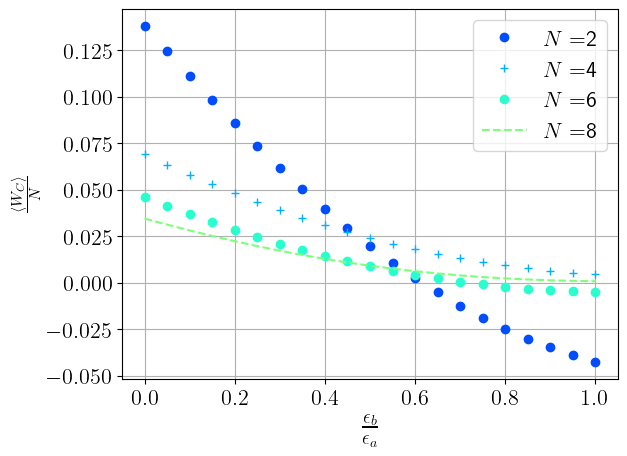

In [ ]:
def thetas_c(e,b,ea=1,ba=1):
 #parametro de correlação
  #parametros do sistema
  bb=b*ba
  eb=e*ea
  #hamiltoniana do sitema
  sz=np.array([[1, 0], [0, -1]])

  H_A=-0.5*ea*sz
  H_B=-0.5*eb*sz

  # Função partição
  Za = np.trace(expm(-ba * H_A))

  Zb = np.trace(expm(-bb * H_B))
  #operador densidade

  p_a=np.exp(ba*ea/2)/Za
  p_b=np.exp(bb*eb/2)/Zb
  #coeficiente

  a=1/(Za*Zb)

  pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

  pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

  x=((p_b-p_a)/(pp-pm)+1)*0.5
  #angulo para rotação x
  theta_a=2*np.arccos(np.sqrt(pp))
  theta_b=2*np.arccos(np.sqrt(pm))

  return theta_a,theta_b,x

b=2
colors = plt.cm.jet(np.linspace(0,1,21))
types=['o','r+','bo','--']
for fig,i in enumerate(tqdm(range(4,11,2))):

  box1=cnots_n(i)
  box2=boxs_par_swap(i)

  dimension=cnot(i,0,1).dims
  rho0_r=Qobj(qt.basis(2**i,0),dims=[dimension[0],[1]])
  trace_ind=np.linspace(1,i-2,i-2,dtype=int)
  ener=np.linspace(0,1,21)
  w1=np.zeros(len(ener),dtype=complex)
  #w2=np.zeros(len(ener),dtype=complex)

  for j,e in enumerate(ener):
    #estado inicial
    rho0=rho0_r

    theta_a,theta_b,x=thetas_c(e,b)

    rho_therma_corr1=boxs_correlation(i,x)*box1*Rxs(theta_a,theta_b,i)*rho0

    #calculando rho final
    rho0=rho_therma_corr1*rho_therma_corr1.dag()
    rho_therma_corr1=box2*rho_therma_corr1
    rhof=rho_therma_corr1*rho_therma_corr1.dag()

    #calculo do trabalho
    w1[j]=(((ptrace(rhof,trace_ind)-ptrace(rho0,trace_ind))*hamiltoniana(e,1,i)).tr())


    '''rho0=rho0_r
    theta_a,theta_b,x=thetas_u(e,b)

    rho_therma_corr1=boxs_correlation(i,x)*box1*Rxs(theta_a,theta_b,i)*rho0

    #calculando rho final
    rho0=rho_therma_corr1*rho_therma_corr1.dag()
    rho_therma_corr1=box2*rho_therma_corr1
    rhof=rho_therma_corr1*rho_therma_corr1.dag()

    #calculo do trabalho
    w2[j]=(((ptrace(rhof,trace_ind)-ptrace(rho0,trace_ind))*hamiltoniana(e,1,i)).tr())'''
  #m=(i-2)
  plt.plot(ener,(w1)/(i-2),types[fig],label=f'$N=${i-2}',color=colors[i])

plt.legend()
plt.grid()
plt.ylabel('$\\frac{\\langle W_C \\rangle }{N}$')
plt.xlabel('$ \\frac{\\epsilon_{b}}{\\epsilon_{a}}$',fontsize=20)
plt.show()

100%|██████████| 21/21 [35:07<00:00, 100.37s/it]


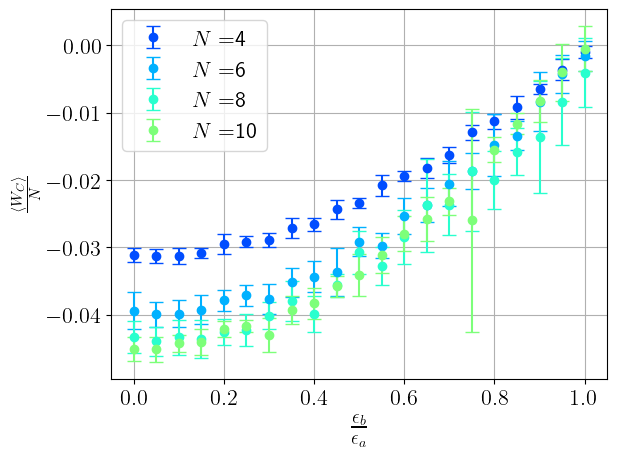

In [ ]:
for nume,num_qubits in enumerate(range(4,11,2)):
  n=21
  ebs=np.linspace(0,1,n)
  expval_med=np.linspace(0,1,n)
  expval_var=np.linspace(0,1,n)
  expval1=np.linspace(0,1,n)
  expval2=np.linspace(0,1,n)
  sum=[]
  #plot=Plots()
  for i,eb in enumerate(tqdm(ebs)):
    Quan7=QuantumCircuits(num_qubits,eb,10000*(num_qubits-2),"qiskit.aer",FakeAlgiers())
    theta_a,theta_b,x=Quan7.thetas_c()
    for j in range(10):#fazendo média
      expval1=Quan7.phi_inicial(theta_a,theta_b,x)
      expval2=Quan7.phi_final(theta_a,theta_b,x)
      sum.append(-expval2+expval1)
    expval_med[i]=np.mean(sum)
    expval_var[i]=np.std(sum)
    sum=[]
  plt.errorbar(ebs,expval_med/(num_qubits),expval_var/(num_qubits), fmt='o', capsize=5,label=f'$N=${(num_qubits)}',color=colors[num_qubits])
plt.ylabel('$\\frac{\\langle W_C \\rangle }{N}$')
plt.xlabel('$ \\frac{\\epsilon_{b}}{\\epsilon_{a}}$',fontsize=20)
plt.legend()
plt.grid(True)
plt.show()

#### Variando a correlação $\alpha$

/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


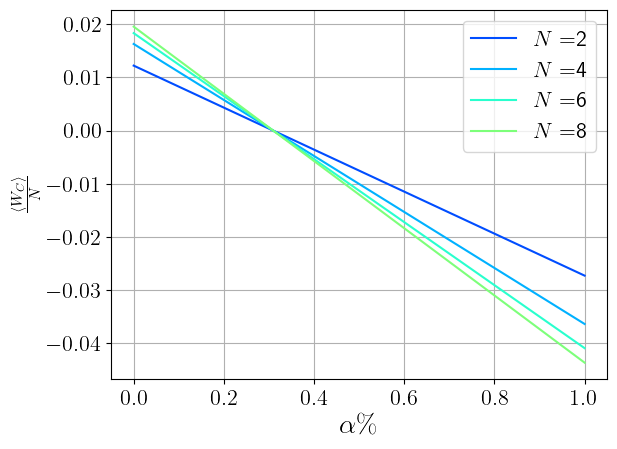

In [ ]:
def thetas_alpha(e,b,p,ea=1,ba=1):
 #parametro de correlação
  #parametros do sistema
  bb=b*ba
  eb=e*ea
  #hamiltoniana do sitema
  sz=np.array([[1, 0], [0, -1]])

  H_A=-0.5*ea*sz
  H_B=-0.5*eb*sz

  # Função partição
  Za = np.trace(expm(-ba * H_A))

  Zb = np.trace(expm(-bb * H_B))
  #operador densidade

  p_a=np.exp(ba*ea*0.5)/Za
  p_b=np.exp(bb*eb*0.5)/Zb
  #coeficiente

  a=p/(Za*Zb)

  pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

  pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

  x=((p_b-p_a)/(pp-pm)+1)*0.5
  #angulo para rotação x
  theta_a=2*np.arccos(np.sqrt(pp))
  theta_b=2*np.arccos(np.sqrt(pm))

  return theta_a,theta_b,x

b=2
alphs=np.linspace(0,1,21)
e=0.25
colors = plt.cm.jet(np.linspace(0,1,21))
for fig,i in enumerate(range(4,11,2)):

  box1=cnots_n(i)
  box2=boxs_par_swap(i)

  dimension=cnot(i,0,1).dims
  rho0_r=Qobj(qt.basis(2**i,0),dims=[dimension[0],[1]])
  trace_ind=np.linspace(1,i-2,i-2,dtype=int)

  w1=np.zeros(len(ener),dtype=complex)
  w2=np.zeros(len(ener),dtype=complex)

  for j,p in enumerate(alphs):

    #estado inicial
    rho0=rho0_r#rho reset

    theta_a,theta_b,x=thetas_alpha(e,b,p)

    rho_therma_corr1=boxs_correlation(i,x)*box1*Rxs(theta_a,theta_b,i)*rho0

    #calculando rho final
    rho0=rho_therma_corr1*rho_therma_corr1.dag()
    rho_therma_corr1=box2*rho_therma_corr1
    rhof=rho_therma_corr1*rho_therma_corr1.dag()

    #calculo do trabalho
    w1[j]=(((ptrace(rhof,trace_ind)-ptrace(rho0,trace_ind))*hamiltoniana(e,1,i)).tr())

  plt.plot(ener,(w1)/i,label=f'$N=${i-2}',color=colors[i])
plt.legend()
plt.grid()
plt.ylabel('$\\frac{\\langle W_C \\rangle}{N}$')
plt.xlabel('$ \\alpha \\%$',fontsize=20)
plt.show()

#### Variando a $\lambda$

/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


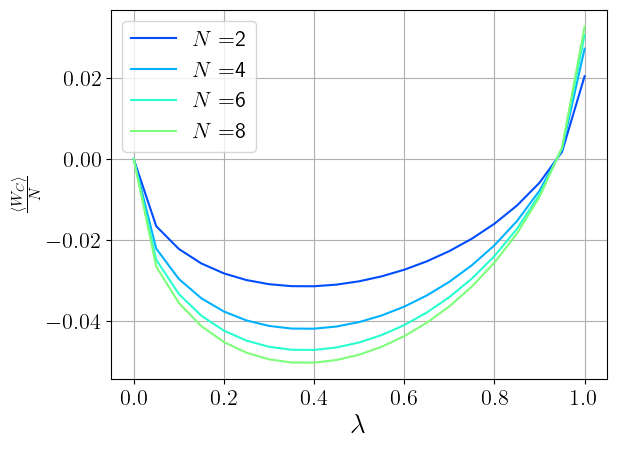

In [ ]:
def thetas_lambda(e,b,p,ea=1,ba=1):
 #parametro de correlação
  #parametros do sistema
  bb=b*ba
  eb=e*ea
  #hamiltoniana do sitema
  sz=np.array([[1, 0], [0, -1]])

  H_A=-0.5*ea*sz
  H_B=-0.5*eb*sz

  # Função partição
  Za = np.trace(expm(-ba * H_A))

  Zb = np.trace(expm(-bb * H_B))
  #operador densidade

  p_a=np.exp(-ba*ea*0.5)/Za
  p_b=np.exp(-bb*eb*0.5)/Zb
  #coeficiente

  a=1/(Za*Zb)

  pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

  pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

  x=((p_b-p_a)/(pp-pm)+1)*0.5
  #angulo para rotação x
  theta_a=2*np.arccos(np.sqrt(pp))
  theta_b=2*np.arccos(np.sqrt(pm))

  return theta_a,theta_b,x

def boxs_par_swap_lamb(num_qubits,lamb):
  #gerando a matriz identidade para gerar os circuitos
  result=Qobj(qeye(2**num_qubits),dims=(cnot(num_qubits,0,1).dims))
  inteiro=int(num_qubits/2)
  #multiplicando as portas lógicas
  for i in range(inteiro):
    result=Qobj(box_par_swap(num_qubits,(inteiro-(i+1)),(inteiro+i),lamb),dims=(cnot(num_qubits,0,1).dims))*result
  return result

b=2
lambs=np.linspace(0,1,21)
e=0.25
colors = plt.cm.jet(np.linspace(0,1,21))
for fig,i in enumerate(range(4,11,2)):

  box1=cnots_n(i)
  box2=boxs_par_swap(i)

  dimension=cnot(i,0,1).dims
  rho0_r=Qobj(qt.basis(2**i,0),dims=[dimension[0],[1]])
  trace_ind=np.linspace(1,i-2,i-2,dtype=int)

  w1=np.zeros(len(ener),dtype=complex)
  w2=np.zeros(len(ener),dtype=complex)

  for j,lamb in enumerate(lambs):

    #estado inicial
    rho0=rho0_r#rho reset

    box2=boxs_par_swap_lamb(i,lamb)

    theta_a,theta_b,x=thetas_c(e,b)

    rho_therma_corr1=boxs_correlation(i,x)*box1*Rxs(theta_a,theta_b,i)*rho0

    #calculando rho final
    rho0=rho_therma_corr1*rho_therma_corr1.dag()
    rho_therma_corr1=box2*rho_therma_corr1
    rhof=rho_therma_corr1*rho_therma_corr1.dag()

    #calculo do trabalho
    w1[j]=(((ptrace(rhof,trace_ind)-ptrace(rho0,trace_ind))*hamiltoniana(e,1,i)).tr())

  plt.plot(ener,(w1)/i,label=f'$N=${i-2}',color=colors[i])
plt.legend()
plt.grid()
plt.ylabel('$\\frac{\\langle W_C \\rangle}{N}$')
plt.xlabel('$ \\lambda$',fontsize=20)
plt.show()

## Circuito gráficos

In [ ]:
from qiskit import QuantumCircuit

In [ ]:
# Build a quantum circuit
circuit = QuantumCircuit(3, 3)
circuit.x(1)
circuit.h(range(3))
circuit.cx(0, 1)
circuit.measure(range(3), range(3));

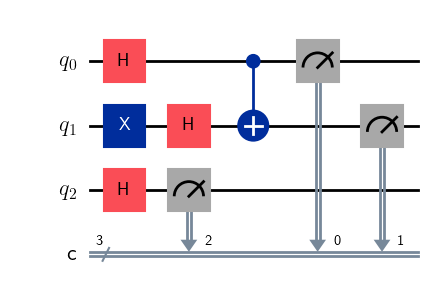

In [ ]:
# Matplotlib drawing
circuit.draw(output="mpl")

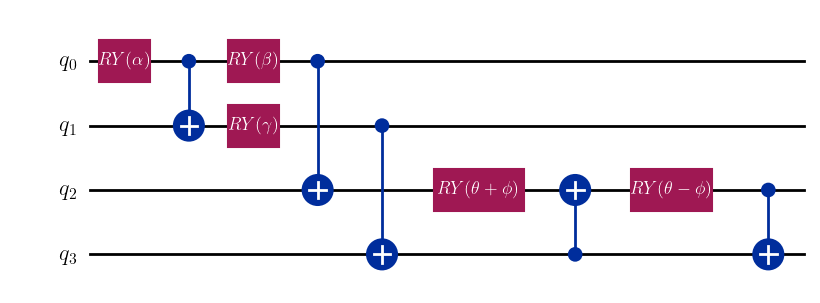

In [ ]:
qc = QuantumCircuit(4)  # Cria um circuito com 4 qubits
# Exemplo de uso:

beta = Parameter('')
qc.ry(beta , 0, label=r'$RY(\alpha)$')
qc.cx(0, 1)
qc.ry(beta, 0, label=r'$RY(\beta)$')
qc.ry(beta , 1, label=r'$RY(\gamma)$')
qc.cx(0, 2)
qc.cx(1, 3)
qc.ry(beta , 2, label=r'$RY(\theta + \phi)$')
qc.cx(3, 2)
qc.ry(beta , 2, label=r'$RY(\theta - \phi)$')
qc.cx(2, 3)

qc.draw(output="mpl")

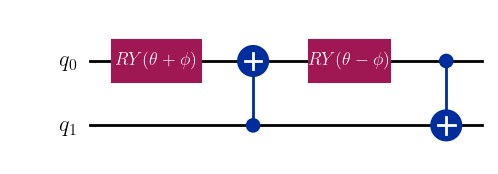

In [ ]:
qc = QuantumCircuit(2)  # Cria um circuito com 4 qubits
# Exemplo de uso:

beta = Parameter('')
qc.ry(beta , 0, label=r'$RY(\theta + \phi)$')
qc.cx(1, 0)
qc.ry(beta , 0, label=r'$RY(\theta - \phi)$')
qc.cx(0, 1)

qc.draw(output="mpl")

In [ ]:
from qiskit import QuantumCircuit
import numpy as np
import matplotlib.pyplot as plt

qc = QuantumCircuit(4)

alpha = np.pi / 4
beta = np.pi / 2
gamma = np.pi / 3
theta = np.pi / 6
phi = np.pi / 8

qc.ry(alpha, 0, label=r'$\alpha$')
qc.cx(0, 1)
qc.ry(beta, 0, label=r'$\beta$')
qc.ry(gamma, 1, label=r'$\gamma$')
qc.cx(0, 2)
qc.cx(1, 3)
qc.ry(theta + phi, 2, label=r'$\theta + \phi$')
qc.cx(3, 2)
qc.ry(theta - phi, 2, label=r'$\theta - \phi$')
qc.cx(2, 3)

fig = qc.draw(output="mpl")

# Para mostrar o gráfico
plt.show()

# Para salvar o gráfico
fig.savefig("circuito_latex.png")

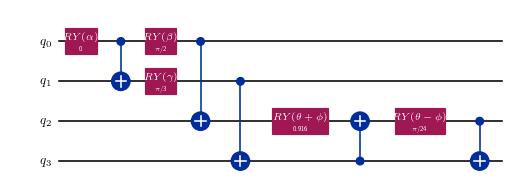

In [ ]:
from qiskit import QuantumCircuit
import numpy as np
import matplotlib.pyplot as plt

qc = QuantumCircuit(4)

alpha = np.pi / 4
beta = np.pi / 2
gamma = np.pi / 3
theta = np.pi / 6
phi = np.pi / 8

qc.ry(0, 0, label=r'$RY(\alpha)$')
qc.cx(0, 1)
qc.ry(beta, 0, label=r'$RY(\beta)$')
qc.ry(gamma, 1, label=r'$RY(\gamma)$')
qc.cx(0, 2)
qc.cx(1, 3)
qc.ry(theta + phi, 2, label=r'$RY(\theta + \phi)$')
qc.cx(3, 2)
qc.ry(theta - phi, 2, label=r'$RY(\theta - \phi)$')
qc.cx(2, 3)

# Use matplotlib backend for more control over labels
fig, ax = plt.subplots()
ax.axis('off')  # Hide the axes
qc.draw(output='mpl', ax=ax)
plt.show()

### Inomogêneo